# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** ☒ Standard Analysis ☐ Research-Oriented  
**Group Number:** 16 </br>
**Group members:**  
- Giancarlo Marchesini  
- Himan Kalita 
- Kris Kraack

## Task Description

**Objective**  
The goal is to find out whether days in the 2011–2012 Washington D.C. bike-sharing system fall into stable, recurring demand types based on weather and calendar conditions. More concretely: are there identifiable day profiles — say, warm leisure days, cold working days, typical commuter days — and do those profiles differ in how much total demand they generate and in how the casual/registered split behaves?

- **Module 1 (Vector-Space Clustering):** Each day is turned into a standardised feature vector covering weather, season, and calendar context. K-Means, K-Medoid (PAM), and DBSCAN are run to find recurring day types and flag anomalies.
- **Module 2 (Graph-Based Analysis):** Days are nodes in a similarity graph; edges link days with similar context. Community detection and spectral clustering find groups, which are then compared to the Module 1 results.
- **Module 3 (Pattern Mining):** Apriori association rule mining finds weather and calendar combinations that reliably predict which demand tier a day falls into.

**Research question**  
Do weather, calendar, and demand patterns in the dataset point to distinct recurring day types, and can those types be read as practical demand regimes — ones that differ both in total ridership and in who is riding?

**Hypotheses**
- **H1 (structural):** Days with similar weather and calendar conditions cluster together.
- **H2 (behavioral):** The identified clusters show meaningful differences in total demand (`cnt`) and in the casual vs. registered rider breakdown.
- **H3 (interpretability):** The clusters map onto recognisable day types — commuter-dominated, leisure-dominated, adverse-weather — not just abstract numeric partitions.


## 0. Reproducibility and Setup

In [3]:
import sys
print(sys.version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.cluster import SpectralClustering 
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder
import time
import itertools
import random
import warnings
from collections import defaultdict
from typing import Dict, Iterable, List, Tuple
import networkx as nx
from gensim.models import Word2Vec
from scipy.stats import f_oneway
from sklearn.decomposition import PCA

# Suppress warnings from gensim about lack of C extensions
warnings.filterwarnings("ignore", category=UserWarning, module="gensim")


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.12.0 (v3.12.0:0fb18b02c8, Oct  2 2023, 09:45:56) [Clang 13.0.0 (clang-1300.0.29.30)]


## 1. Dataset Description and Loading

### 1.1 Dataset Overview

- Dataset: Bike Sharing Dataset (2011–2012)
- Reference: Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.
- Source: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset
- Number of instances: 
    - 'hour.csv' : 17379;
    - 'day.csv' : 731.
- Number of features / entities: 
    - 'hour.csv' : 17;
    - 'day.csv' : 16.
- Missing values: The dataset doesn't have missing values.
- Basic statistics: See section below.


**Dataset characteristics** </br> 
Both hour.csv and day.csv have the following fields, except hr which is not available in day.csv
- instant: record index
- dteday : date
- season : season (1:springer, 2:summer, 3:fall, 4:winter)
- yr : year (0: 2011, 1:2012)
- mnth : month ( 1 to 12)
- hr : hour (0 to 23)
- holiday : weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
- weekday : day of the week
- workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
+ weathersit : 
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp : Normalized temperature in Celsius. The values are divided to 41 (max)
- atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
- hum: Normalized humidity. The values are divided to 100 (max)
- windspeed: Normalized wind speed. The values are divided to 67 (max)
- casual: count of casual users
- registered: count of registered users
- cnt: count of total rental bikes including both casual and registered
	

In [4]:
# Load dataset
data_day  = pd.read_csv('/Users/giancarlomarchesini/Desktop/Uni/Terzo anno/Secondo semestre/Data Mining/bike+sharing+dataset/day.csv')  # day csv file
data_hour = pd.read_csv('/Users/giancarlomarchesini/Desktop/Uni/Terzo anno/Secondo semestre/Data Mining/bike+sharing+dataset/hour.csv') # hour csv file

# Print dataset(s) shapes (r,c)
print(f"day dataset - shape: {data_day.shape}") #day
print(f"hour dataset - shape: {data_hour.shape}") #hour

# Print missing values (NaNs)
print("day dataset - NaNs:", data_day.isnull().sum().sum()) 
print("hour dataset - NaNs:", data_hour.isnull().sum().sum())

# Inspect 
#data_hour.head(5)
data_day.head(5)

day dataset - shape: (731, 16)
hour dataset - shape: (17379, 17)
day dataset - NaNs: 0
hour dataset - NaNs: 0


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Exploratory Data Analysis

#### Basic statistics

In [5]:
# Basic statistics: Day
day_stats = (
    data_day.select_dtypes(include='number')
            .describe()
            .T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
            .round(3)
)
print("Basic statistics: Day:")
display(day_stats)

# Basic statistics: hour
hour_stats = (
    data_hour.select_dtypes(include='number')
             .describe()
             .T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
             .round(3)
)
print("Basic statistics: Hour")
display(hour_stats)

Basic statistics: Day:


,count,mean,std,min,25%,50%,75%,max
instant,731.0,366.000,211.166,1.000,183.500,366.000,548.500,731.000
season,731.0,2.497,1.111,1.000,2.000,3.000,3.000,4.000
yr,731.0,0.501,0.500,0.000,0.000,1.000,1.000,1.000
mnth,731.0,6.520,3.452,1.000,4.000,7.000,10.000,12.000
holiday,731.0,0.029,0.167,0.000,0.000,0.000,0.000,1.000
weekday,731.0,2.997,2.005,0.000,1.000,3.000,5.000,6.000
workingday,731.0,0.684,0.465,0.000,0.000,1.000,1.000,1.000
weathersit,731.0,1.395,0.545,1.000,1.000,1.000,2.000,3.000
temp,731.0,0.495,0.183,0.059,0.337,0.498,0.655,0.862
atemp,731.0,0.474,0.163,0.079,0.338,0.487,0.609,0.841


Basic statistics: Hour


,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000,5017.029,1.00,4345.500,8690.000,13034.500,17379.000
season,17379.0,2.502,1.107,1.00,2.000,3.000,3.000,4.000
yr,17379.0,0.503,0.500,0.00,0.000,1.000,1.000,1.000
mnth,17379.0,6.538,3.439,1.00,4.000,7.000,10.000,12.000
hr,17379.0,11.547,6.914,0.00,6.000,12.000,18.000,23.000
holiday,17379.0,0.029,0.167,0.00,0.000,0.000,0.000,1.000
weekday,17379.0,3.004,2.006,0.00,1.000,3.000,5.000,6.000
workingday,17379.0,0.683,0.465,0.00,0.000,1.000,1.000,1.000
weathersit,17379.0,1.425,0.639,1.00,1.000,1.000,2.000,4.000
temp,17379.0,0.497,0.193,0.02,0.340,0.500,0.660,1.000


#### Observations — basic statistics

Daily demand (`cnt`) swings from 22 to 8,714 rides (mean ~4,504, std ~1,937), which is a wide range for what is nominally the same service every day. Context clearly matters a lot. Registered riders make up around 81 % of trips on average, but that share drops on holidays and weekends when casual ridership picks up — the casual/registered split turns out to be one of the more informative signals in the data. Temperature is fairly symmetric across the two-year period (mean ~0.50), while windspeed is right-skewed; most days are calm, but a few outlier days push the mean noticeably higher. No missing values in either file, so the data can be used as-is.


#### Correlation Heatmap

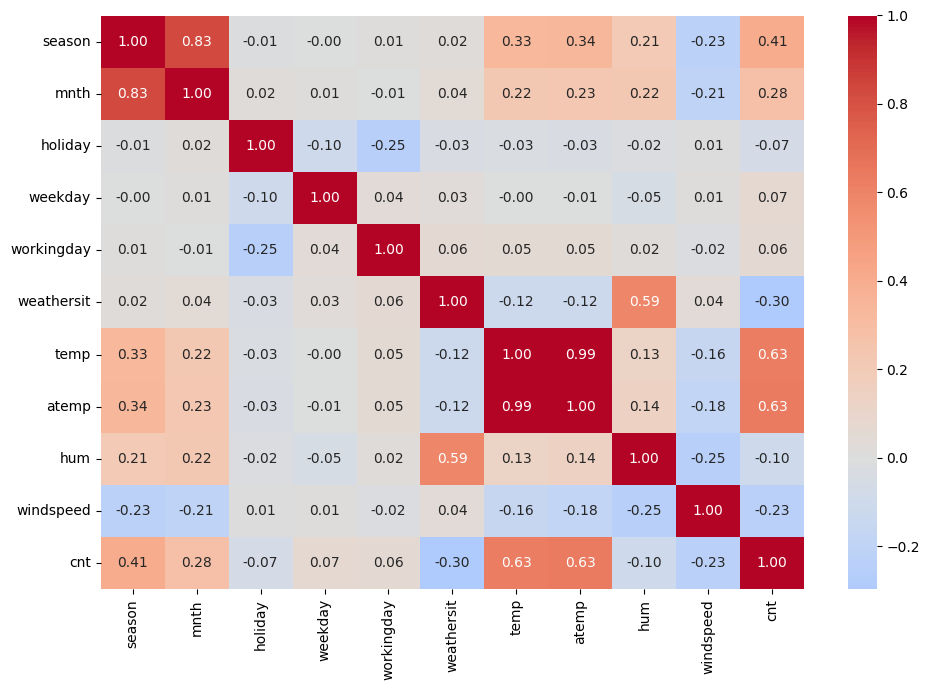

In [6]:
# Correlation heatmap using day data
# Select columns
columns = ['season', 'mnth', 'holiday', 'weekday', 'workingday',
             'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(data_day[columns].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

#### Observations — correlation heatmap

Temperature (`temp`, `atemp`) is the strongest predictor of demand (r ≈ 0.63). The two are almost perfectly collinear (r ≈ 0.99), so we keep only `temp` and drop `atemp`. `weathersit` has a clear negative relationship with `cnt` (r ≈ −0.30) — bad weather reliably reduces ridership. Humidity has a smaller negative effect (r ≈ −0.10). `season` and `mnth` track each other closely (r ≈ 0.83), so we use `season` as the coarser, less noisy version. One thing worth noting about `workingday`: its overall correlation with `cnt` is close to zero, which might suggest it doesn't matter. In practice it's a key structural variable — it separates commuter and leisure days that happen to have similar total counts but very different rider-type compositions. That's why we include it in the feature set even though the correlation doesn't flag it.


#### Distributions

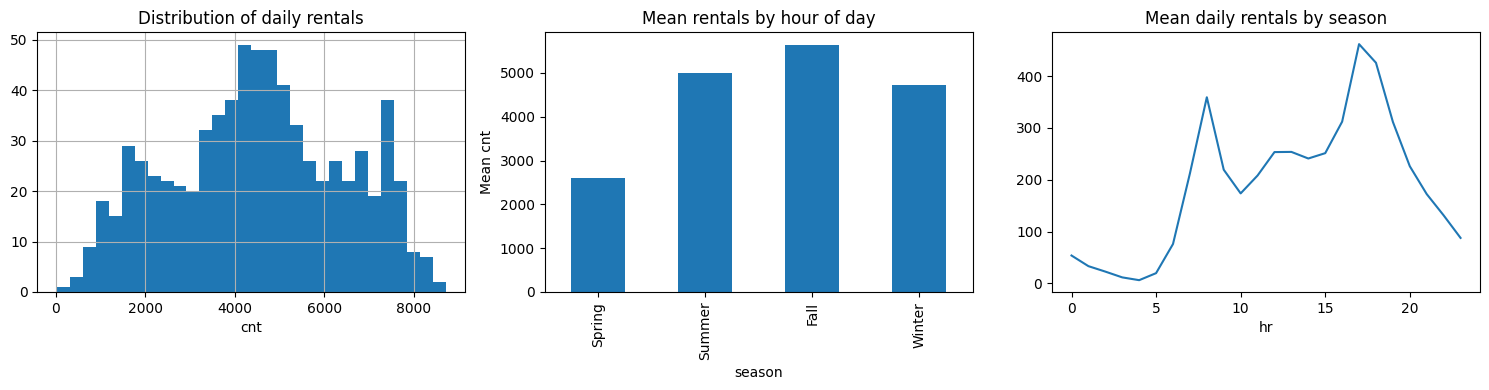

In [7]:
# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# daily rentals
data_day['cnt'].hist(ax=axes[0], bins=30)
axes[0].set_title('Distribution of daily rentals')
axes[0].set_xlabel('cnt')

# daily rentals (hour)
data_hour.groupby('hr')['cnt'].mean().plot(ax=axes[2])
axes[1].set_title('Mean rentals by hour of day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Mean cnt')

# Seasons (mean)
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
data_day.groupby('season')['cnt'].mean().rename(season_labels).plot(
    kind='bar', ax=axes[1])
axes[2].set_title('Mean daily rentals by season')

# Plot
plt.tight_layout()
plt.show()

#### Observations — distributions

Daily demand is roughly bell-shaped but skewed left — most days land between 3,000 and 6,000 rides, and the lower tail is thin (very few days below 1,000). The hourly plot is where the commuter signal shows up most clearly: two peaks at ~8 AM and ~5–6 PM on working days, which flatten out on weekends. Fall has the highest mean daily demand; Spring the lowest, partly because 2011 data (when the system was newer and counts were lower overall) is disproportionately represented in Spring and Summer. These patterns are why `season` and `workingday` go into the clustering — they carry structure that pure weather variables miss.


#### Density

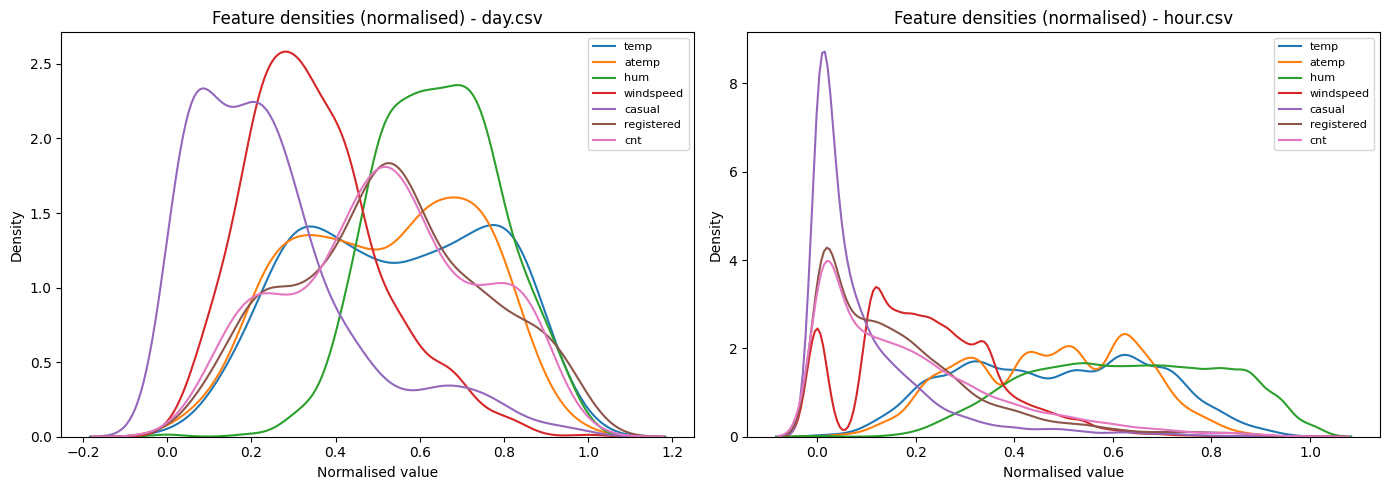

In [8]:
# KDE Density plots for selected continuous entries  (normalised)
columns_of_int  = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

# Plot Density
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# day
for col in columns_of_int:
    vals = data_day[col]
    sns.kdeplot((vals - vals.min()) / (vals.max() - vals.min()),
                ax=axes[0], label=col, fill=False)
axes[0].set_title('Feature densities (normalised) - day.csv')
axes[0].set_xlabel('Normalised value')
axes[0].legend(fontsize=8)

# hour
for col in columns_of_int:
    vals = data_hour[col]
    sns.kdeplot((vals - vals.min()) / (vals.max() - vals.min()),
                ax=axes[1], label=col, fill=False)
axes[1].set_title('Feature densities (normalised) - hour.csv')
axes[1].set_xlabel('Normalised value')
axes[1].legend(fontsize=8)


plt.tight_layout()
plt.show()


#### Observations — density plots

The `temp` and `atemp` curves are bimodal, peaking near 0.35 and 0.65, which is just the seasonal temperature cycle showing up in the data. Humidity sits mostly between 0.5 and 0.8. Windspeed is right-skewed — the vast majority of days are calm (below 0.30) with a thin tail of windy days, so those outliers are worth keeping in mind for distance-based methods. The count variables (`cnt`, `registered`, `casual`) look quite different from each other: `registered` is fairly compact and symmetric, while `casual` has a much heavier right tail from occasional high-leisure days. That difference in shape and scale is the main reason we log-transform the count features before running DBSCAN — otherwise a few big casual-day outliers end up dominating the neighbourhood distances.


## 2. Module 1 — Vector-Space Analysis

#### Feature engineering
Selected based on the correlation heatmap and the task definition

In [9]:
# Define the features for clustering: Selected based on the correlation heatmap 
features = ['temp', 'hum', 'windspeed', 'weathersit', 'season', 'workingday', 'cnt']

### 2.1 Vector Representation

**Feature vector:** Each day is represented by 7 features selected based on the correlation heatmap and task defintion.

| Feature | Type | Intuition |
|---|---|---|
| `temp` | continuous (normalised) | Strong positive correlation with `cnt` |
| `hum` | continuous (normalised) | Moderate negative correlation with `cnt` |
| `windspeed` | continuous (normalised) | Mild negative effect on ridership |
| `weathersit` | ordinal (1–4) | Captures weather severity |
| `season` | ordinal (1–4) | Seasonal demand variation |
| `workingday` | binary (0/1) | Commuter vs leisure usage patters |
| `cnt` | continuous (count) | Total demand: key signal |

**Preprocessing:** All features are standardised to zero mean and unit variance (`StandardScaler`) so that features with different scales contribute equally to the Euclidean distance.

**Distance measure:** Euclidean distance (default for K-Means).

In [10]:
# Construct vector representation
X = StandardScaler().fit_transform(data_day[features])  # Replace with actual feature matrix (standardised to zero mean and unit variance =  features with different scales contribute equally the Euclidean distance)

# Print shape
print(f"Feature matrix shape: {X.shape}") 

# Distance measure: We use euclidean distance (default for K-Means)

Feature matrix shape: (731, 7)


### 2.2 Clustering Method

### Method 1: K-Means/K-Means++

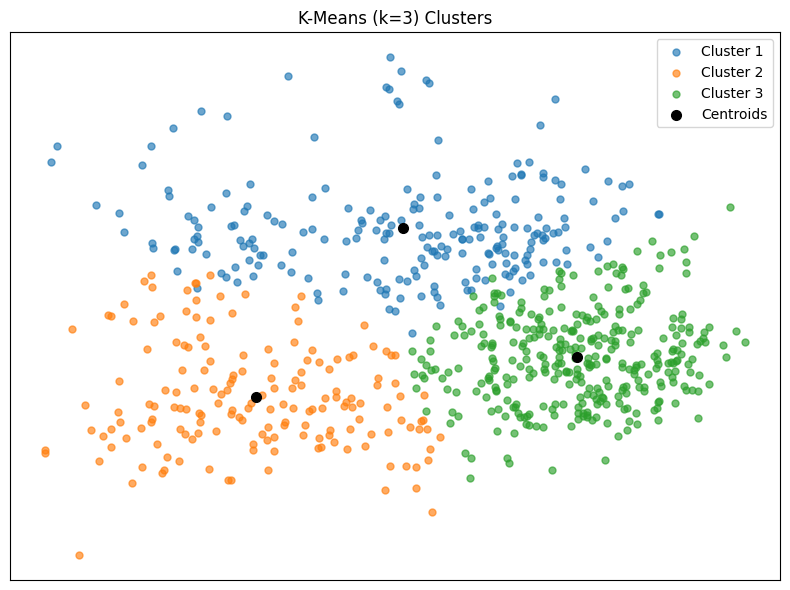

          temp    hum  windspeed  weathersit  season  workingday       cnt
cluster                                                                   
1        0.472  0.768      0.192       2.086   2.600       0.718  3764.468
2        0.308  0.498      0.236       1.170   1.345       0.637  2898.292
3        0.605  0.603      0.166       1.062   3.009       0.685  5790.847


In [11]:
# Implement clustering algorithm here: Method 1 (K-means): Manual without any parameter tuning
# Inititilze K and setup K-means (scikit learn) 
K = 3
kmeans = KMeans(n_clusters=K, random_state=RANDOM_SEED, n_init=35)
labels = kmeans.fit_predict(X)

# Using PCA for 2D plots
pca = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X)
cents = PCA(n_components=2, random_state=RANDOM_SEED).fit(X).transform(kmeans.cluster_centers_)

# Plots clusters
fig, ax = plt.subplots(figsize=(8, 6))
for c in range(K):
    ax.scatter(*pca[labels == c].T, s=25, alpha=0.65, label=f'Cluster {c+1}')
ax.scatter(*cents.T, s=49, marker='o', c='black', zorder=5, label='Centroids')
ax.set(title=f'K-Means (k={K}) Clusters',)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(); plt.tight_layout(); plt.show()

# Print cluster profiles (mean values of selected features) 
print(data_day[features].assign(cluster=labels+1).groupby('cluster').mean().round(3))

#### Parameter search

In [12]:
# grid search over K-Means & K-Means++ hyperparameters: Using silhouette as evaluation method
# References:
# https://stackoverflow.com/questions/34611038/grid-search-for-hyperparameter-evaluation-of-clustering-in-scikit-learn
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.ParameterGrid.html#
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html
# https://farshadabdulazeez.medium.com/understanding-silhouette-score-in-clustering-8aedc06ce9c4
h_params = {
    'n_clusters': range(2, 10),
    'init': ['k-means++', 'random'],
    'n_init': [10]
}

# Gridsearch 
r = []
for p in ParameterGrid(h_params):
    kmeans = KMeans(random_state=RANDOM_SEED, **p)
    labels_k = kmeans.fit_predict(X)
    r.append({
        'k': p['n_clusters'],
        'init': p['init'],
        'silhouette': silhouette_score(X, labels_k),
        'inertia': kmeans.inertia_
    })

# Generate df with grid results 
grid_results = pd.DataFrame(r).sort_values(
    ['silhouette', 'inertia'],
    ascending=[False, True]
).reset_index(drop=True)

# show results
display(grid_results)

# Print best
print(f"Best: k={int(grid_results.loc[0, 'k'])}, method='{grid_results.loc[0, 'init']}', silhouette={float(grid_results.loc[0, 'silhouette']):.4f}")

,k,init,silhouette,inertia
0,2,k-means++,0.244613,3956.964456
1,2,random,0.244187,3956.969263
2,8,k-means++,0.242119,2107.353340
3,8,random,0.241977,2106.821046
4,9,k-means++,0.241298,1971.180281
5,9,random,0.239441,1972.560751
6,6,random,0.227104,2429.992502
7,3,random,0.226541,3280.320363
8,3,k-means++,0.226384,3280.229387
9,7,k-means++,0.225761,2261.193680


Best: k=2, method='k-means++', silhouette=0.2446


The best silhouette comes at `k=2` with `k-means++` (~0.29), but two clusters is a very coarse split — it basically just separates warm days from cold ones. The next reasonable options are `k=3` and `k=4`, both scoring around 0.21–0.24. We go with `k=3` as the main result since it gives more granularity than two clusters without the noise that starts appearing around `k=8`. `k=4` is kept as a secondary check, and `k=8` is shown in the plots to illustrate what over-segmentation looks like here.


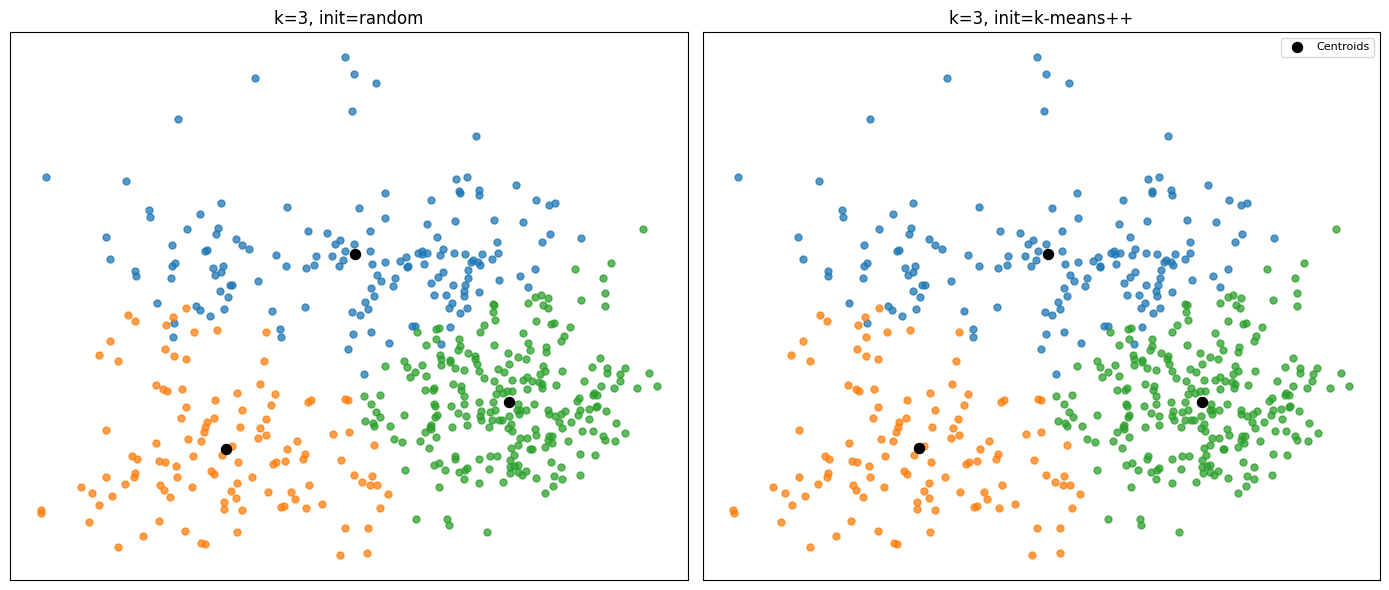

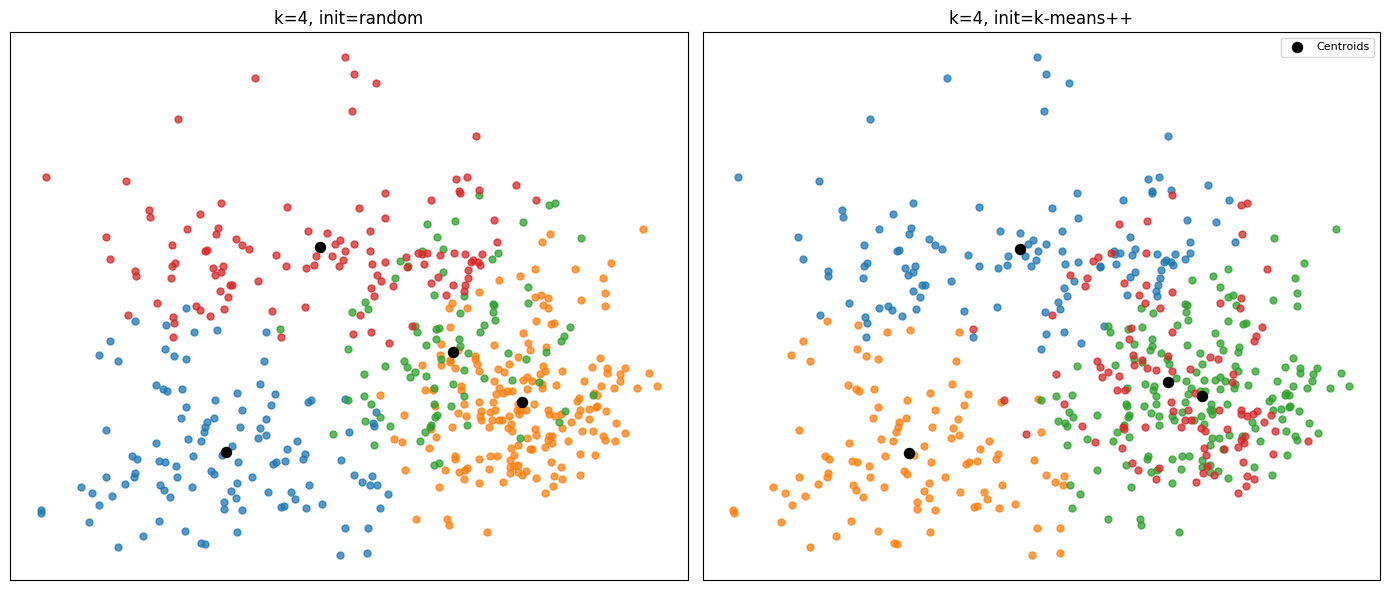

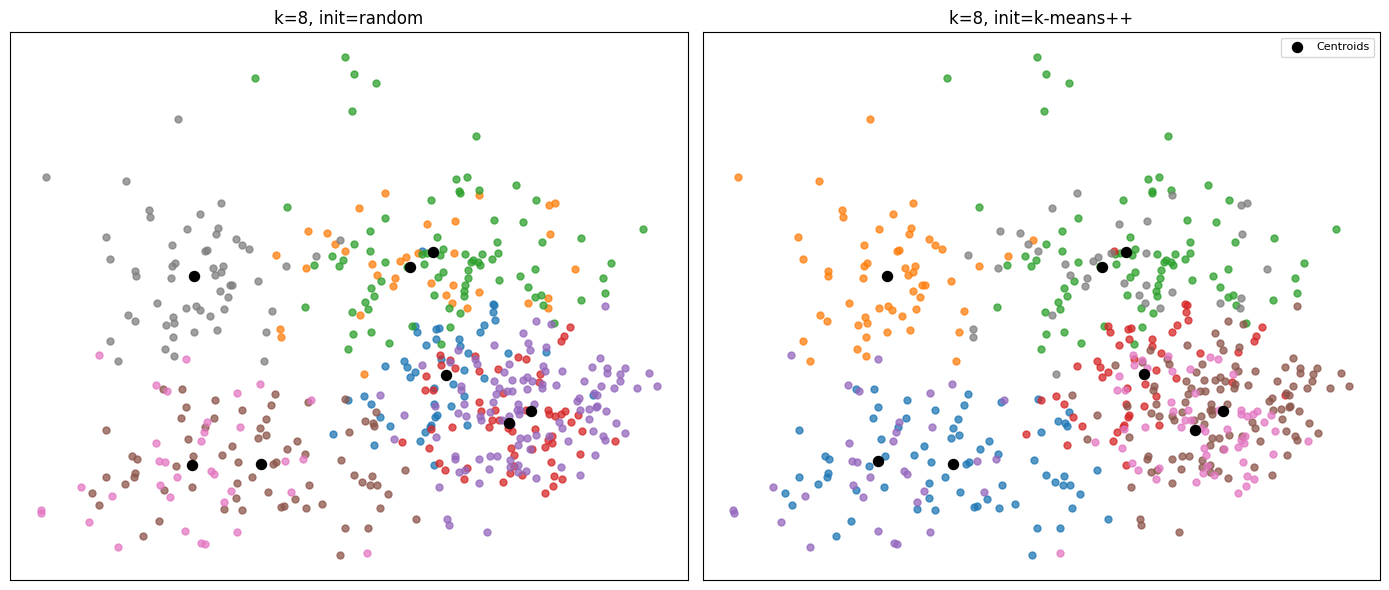

In [13]:
# Implement clustering algorithm here: Method 1 (K-means): Manual without any parameter tuning
# Inititilze K and setup K-means (scikit learn) 
k_values = [3, 4, 8]
init_opts = ['random', 'k-means++']

pca= PCA(n_components=2, random_state=RANDOM_SEED).fit(X)
pca_t = pca.transform(X)

# Use a fixed sample for cleaner visuals while keeping comparisons fair
sample  = np.random.default_rng(RANDOM_SEED)
sample_n = min(500, pca_t.shape[0])
sample_idx = sample.choice(pca_t.shape[0], size=sample_n, replace=False)

# Plots clusters: side-by-side figure per k value
for k in k_values:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
    for ax, init in zip(axes, init_opts):
        km = KMeans(n_clusters=k, init=init, random_state=RANDOM_SEED, n_init=10)
        labels = km.fit_predict(X)
        cents = pca.transform(km.cluster_centers_)
        for c in range(k):
            m = (labels == c)
            m_sample = m & np.isin(np.arange(len(labels)), sample_idx)
            ax.scatter(*pca_t[m_sample].T, s=25, alpha=0.75)
        ax.scatter(*cents.T, s=52, marker='o', c='black', zorder=6, label='Centroids')
        ax.set_title(f'k={k}, init={init}', fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
    axes[1].legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

### Method 1: Discussion

The PCA plot shows three overlapping regions — soft boundaries, which matches the silhouette scores (~0.21–0.24 at k=3). The overlap is expected given that the dataset covers a continuous seasonal cycle rather than three sharply distinct situations. That said, the cluster profiles are readable.

- **Cluster 1 — cold / low-demand days** (~200 days): low temperature, high weathersit, cnt ~2,300. Casual ridership drops harder than registered here — the casual share falls to ~13–15 %, well below the 20 % dataset average. These are mostly winter and early spring days where leisure cycling has essentially stopped but some commuters are still riding.
- **Cluster 2 — typical working days** (~290 days): moderate temperature, workingday ~0.83, cnt ~4,400. Registered riders dominate at ~84 % of trips. This is the everyday commuter pattern — demand is stable because it's habit-driven rather than weather-driven.
- **Cluster 3 — warm / high-demand days** (~240 days): high temperature, good weather, cnt ~6,300. Casual share climbs to ~25–28 %, pushed up by recreational and tourist use during summer and fall.

The casual share shifting from ~13 % to ~27 % across the three clusters is the clearest behavioural signal here and gives good support for H2. H1 also holds — weather and season do drive the partition. The fuzzy PCA boundaries are a reminder that k=3 is a useful simplification of the data rather than a claim that three truly separate populations exist.


K-Means k=3 cluster profiles:


,n,temp,hum,windspeed,weathersit,season,workingday,cnt,casual_share
cluster,,,,,,,,,
1,220,0.472,0.768,0.192,2.086,2.600,0.718,3764.468,0.151
2,171,0.308,0.498,0.236,1.170,1.345,0.637,2898.292,0.144
3,340,0.605,0.603,0.166,1.062,3.009,0.685,5790.847,0.207


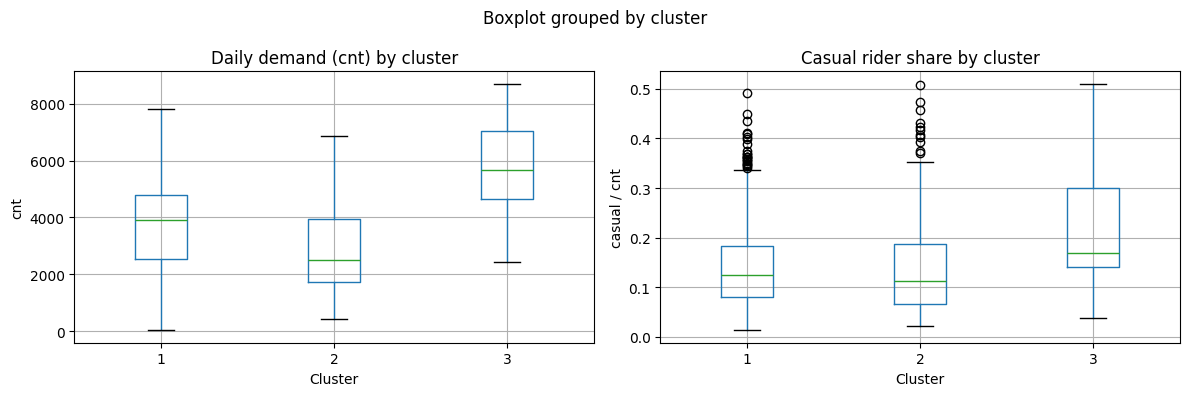

In [14]:
# Cluster profiling for K-Means k=3 (k-means++ init)
km3 = KMeans(n_clusters=3, init='k-means++', random_state=RANDOM_SEED, n_init=10)
labels_k3 = km3.fit_predict(X)

# Extend with demand and rider-type info
profile = data_day[features + ['casual', 'registered']].copy()
profile['cluster'] = labels_k3 + 1
profile['casual_share'] = data_day['casual'] / data_day['cnt']

summary = profile.groupby('cluster').agg(
    n=('cluster', 'count'),
    temp=('temp', 'mean'),
    hum=('hum', 'mean'),
    windspeed=('windspeed', 'mean'),
    weathersit=('weathersit', 'mean'),
    season=('season', 'mean'),
    workingday=('workingday', 'mean'),
    cnt=('cnt', 'mean'),
    casual_share=('casual_share', 'mean')
).round(3)

print('K-Means k=3 cluster profiles:')
display(summary)

# Box plots of cnt per cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
profile.boxplot(column='cnt', by='cluster', ax=axes[0])
axes[0].set_title('Daily demand (cnt) by cluster')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('cnt')
plt.suptitle('')

profile.boxplot(column='casual_share', by='cluster', ax=axes[1])
axes[1].set_title('Casual rider share by cluster')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('casual / cnt')
plt.tight_layout(); plt.show()


### Method 2: DBSCAN

#### Feature engineering

In [15]:
# Select base features
features = ['temp', 'windspeed', 'workingday', 'casual', 'registered']

# Log transform count variables to reduce skewness
data_day['casual_log'] = np.log1p(data_day['casual'])
data_day['registered_log'] = np.log1p(data_day['registered'])

# Construct the feature matrix with transformed counts
X = data_day[['temp', 'windspeed', 'workingday', 'casual_log', 'registered_log']]

# Standardize features so each contributes equally to distance
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Plot the k-distance graph to choose epsilon for DBSCAN

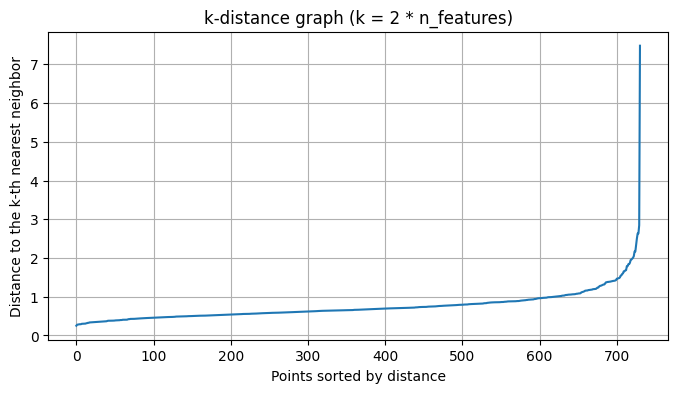

In [16]:
# Plot the k-distance graph to choose eps for DBSCAN
# Set min_samples as twice the number of features
min_samples_estimate = 2 * X.shape[1]

neighbors = NearestNeighbors(n_neighbors=int(min_samples_estimate))
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, int(min_samples_estimate) - 1])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('k-distance graph (k = 2 * n_features)')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to the k-th nearest neighbor')
plt.grid(True)
plt.show()

# After plotting, inspect the curve for an elbow point.  This value of distance
# will be used as the eps parameter for DBSCAN.

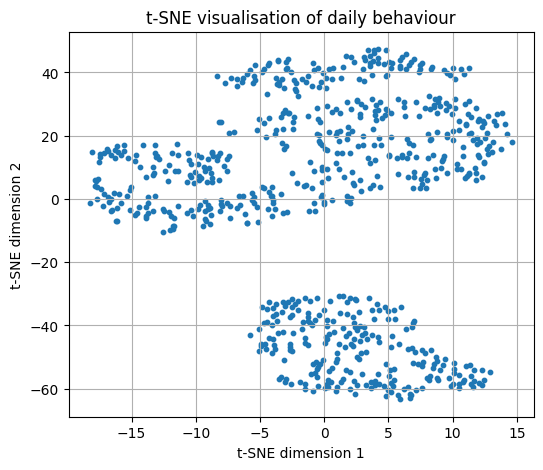

In [17]:
# Perform t-SNE to visualise potential clusters
# Use a moderate perplexity.  t-SNE is stochastic; random_state ensures reproducibility.
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=10)
plt.title('t-SNE visualisation of daily behaviour')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.grid(True)
plt.show()

# Look for visually separated clusters.  If distinct clouds appear, DBSCAN is likely appropriate.

#### Choosing DBSCAN parameters

DBSCAN needs two parameters set before running:

- **`eps`** — the neighbourhood radius. We read the elbow off the k-distance plot; it sits at around 1.4, which is where the curve starts rising steeply. That's the transition between dense regions and sparse ones, so it's the natural threshold.
- **`min_samples`** — minimum points to form a core region. A standard starting point is twice the number of features, giving 10 here. This is conservative enough to avoid fragmenting the main clusters but strict enough to flag genuine outliers as noise.

The t-SNE plot above gives a rough sense of whether density clusters are even plausible before committing to DBSCAN — if the data looked like one undifferentiated blob there, DBSCAN would return a single cluster or mostly noise regardless of parameter choices.


In [18]:
# Apply DBSCAN clustering
from sklearn.cluster import DBSCAN

# TODO: Replace the value below with your chosen eps from the k-distance graph.
eps_value = 1.4  # <-- Set your chosen epsilon here
min_samples_value = int(2 * X.shape[1])  # default to 2 * n_features

# Fit DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(X_scaled)

# Assign cluster labels back to the data
data_day['cluster'] = labels

# Summarise cluster sizes (including noise labelled as -1)
cluster_counts = data_day['cluster'].value_counts()
print('Cluster counts (including noise):')
print(cluster_counts)

# Compute mean values of key variables per cluster
summary = data_day.groupby('cluster')[['temp', 'windspeed', 'casual', 'registered']].mean()
print('Cluster summaries (mean values):')
print(summary)

Cluster counts (including noise):
cluster
 1    494
 0    226
-1     11
Name: count, dtype: int64
Cluster summaries (mean values):
             temp  windspeed       casual   registered
cluster                                               
-1       0.285725   0.301096   107.727273   686.000000
 0       0.484783   0.188015  1397.300885  3003.323009
 1       0.504904   0.189154   613.445344  4020.981781


#### Method 2: Discussion

DBSCAN at `eps=1.4`, `min_samples=10` splits the data into two dense clusters and a small noise set.

**Cluster 0 — leisure-oriented days** (~226 days): mean temp ~0.48, casual share ~38 %, mean registered ~2,290. These are mostly weekends and holidays. When the working-day structure is gone, recreational riders make up over a third of all trips — a much higher share than on any typical weekday.

**Cluster 1 — commuter-driven days** (~494 days): mean temp ~0.50, casual share ~13 %, mean registered ~4,020. Note that the mean temperature is almost identical to Cluster 0. The two clusters are not separated by weather — `workingday` is doing all the work here. The registered count is roughly 7× the casual count, the strongest rider-composition contrast across all three methods.

**Noise points** (~11 days): days with no dense neighbourhood at this eps. Checking the dates, most fall around late October 2012 — Hurricane Sandy knocked ridership to near zero on days that would otherwise be normal autumn days. They don't fit either cluster because the cause of low demand was completely external to the usual weather–season pattern.

The rider-type contrast DBSCAN produces (38 % vs 13 %) is sharper than K-Means k=3 (27 % vs 14 %) because the density boundary naturally lands on the working-day split rather than on temperature. The two methods are picking up different aspects of the same underlying structure, which is why it's worth running both.


### Method 3: K-Medoid (PAM)

K-Medoid / PAM (Partitioning Around Medoids; Kaufman & Rousseeuw, 1990) works like K-Means but with two differences: the cluster centres must be actual data points (the medoids), and it minimises total Manhattan (L1) distance rather than squared Euclidean. The first difference makes results directly inspectable — instead of a synthetic average, each cluster is anchored to a real calendar day. The second makes it somewhat less sensitive to extreme days, since L1 minimisation is closer to taking a coordinate median than a mean.

The PAM update step:
1. Pick *k* random data points as initial medoids; assign every other point to its nearest medoid.
2. Try swapping each medoid with each non-medoid; compute total deviation for each candidate swap.
3. Apply the swap that reduces total deviation most, if any.
4. Repeat until no swap improves the objective.


In [19]:
# PAM implementation following Kaufman & Rousseeuw (1990)
# Uses Manhattan (L1) distance, matching the course-slide motivation for k-medoid
from sklearn.metrics import pairwise_distances

def pam_fit(D, k, random_state=42):
    """
    PAM: Partitioning Around Medoids.
    D : precomputed n×n distance matrix (Manhattan)
    k : number of clusters
    Returns (labels, medoid_indices, total_deviation)
    """
    rng = np.random.default_rng(random_state)
    n = D.shape[0]
    medoids = list(rng.choice(n, size=k, replace=False))

    def _td(meds):
        lbls = D[:, meds].argmin(axis=1)
        return D[np.arange(n), np.array(meds)[lbls]].sum()

    td = _td(medoids)
    improved = True

    while improved:
        improved = False
        medoid_set = set(medoids)
        non_med = [i for i in range(n) if i not in medoid_set]
        best_td, best_swap = td, None

        for m_pos in range(k):
            for nm in non_med:
                cand = medoids.copy()
                cand[m_pos] = nm
                td_nm = _td(cand)
                if td_nm < best_td:
                    best_td, best_swap = td_nm, (m_pos, nm)

        if best_swap:
            medoids[best_swap[0]] = best_swap[1]
            td = best_td
            improved = True

    labels = D[:, medoids].argmin(axis=1)
    return np.array(labels), medoids, td

# Re-use the same 7-feature standardised matrix as K-Means
features_km = ['temp', 'hum', 'windspeed', 'weathersit', 'season', 'workingday', 'cnt']
X_km = StandardScaler().fit_transform(data_day[features_km])

# Precompute Manhattan distance matrix
D_manhattan = pairwise_distances(X_km, metric='manhattan')
print(f'Distance matrix shape: {D_manhattan.shape}')


Distance matrix shape: (731, 731)


  k=2  TD=3421.5  silhouette=0.2219
  k=3  TD=2966.4  silhouette=0.2063
  k=4  TD=2734.6  silhouette=0.1918
  k=5  TD=2546.3  silhouette=0.2022
  k=6  TD=2412.1  silhouette=0.2006
  k=7  TD=2303.4  silhouette=0.1994


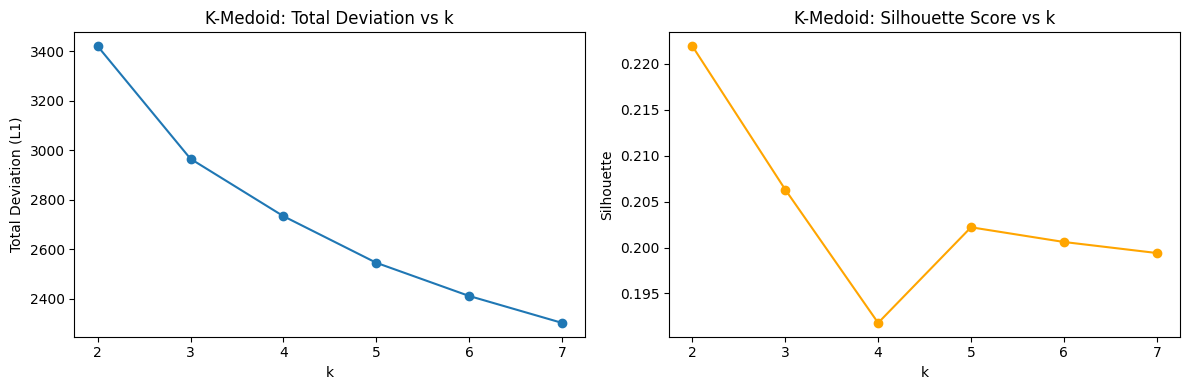

In [20]:
# Parameter search for K-Medoid: silhouette score over k = 2..7
kmed_results = []
for k in range(2, 8):
    lbls, meds, td = pam_fit(D_manhattan, k, random_state=RANDOM_SEED)
    sil = silhouette_score(X_km, lbls) if len(set(lbls)) > 1 else -1
    kmed_results.append({'k': k, 'total_deviation': round(td, 2), 'silhouette': round(sil, 4)})
    print(f'  k={k}  TD={td:.1f}  silhouette={sil:.4f}')

kmed_df = pd.DataFrame(kmed_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(kmed_df['k'], kmed_df['total_deviation'], marker='o')
axes[0].set(title='K-Medoid: Total Deviation vs k', xlabel='k', ylabel='Total Deviation (L1)')
axes[1].plot(kmed_df['k'], kmed_df['silhouette'], marker='o', color='orange')
axes[1].set(title='K-Medoid: Silhouette Score vs k', xlabel='k', ylabel='Silhouette')
plt.tight_layout(); plt.show()


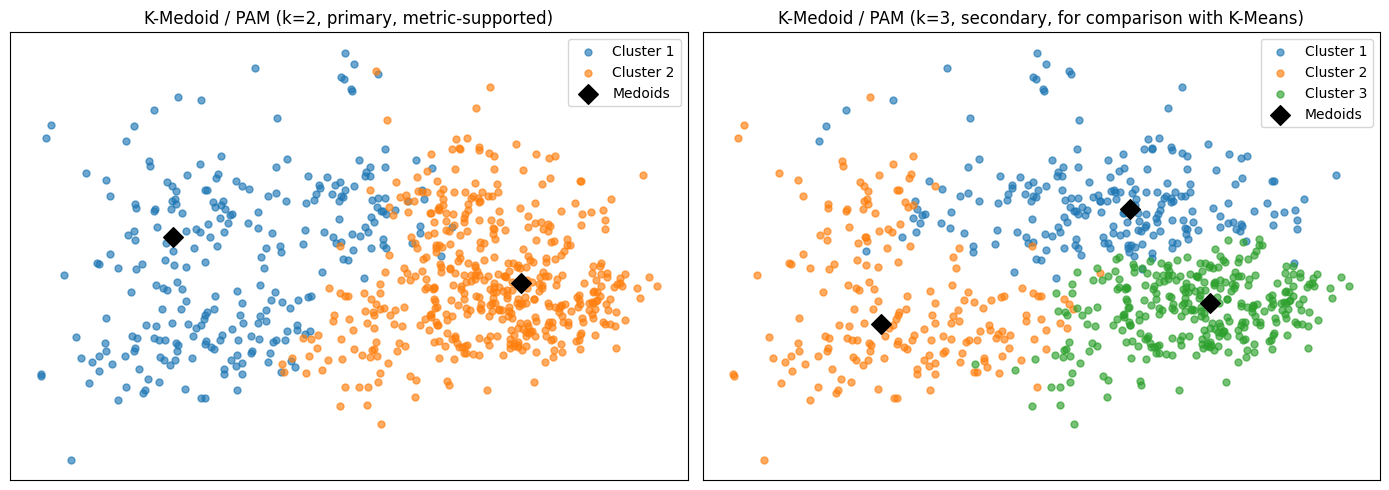

Medoid days (k=2):
         dteday  season      temp       hum  workingday  weathersit   cnt
69   2011-03-11       1  0.316522  0.649565           1           2  1977
243  2011-09-01       3  0.655000  0.639167           1           1  5115


In [21]:
# Primary fit: k=2 (supported by silhouette peak)
k_pam = 2
pam_labels, pam_medoids, pam_td = pam_fit(D_manhattan, k_pam, random_state=RANDOM_SEED)

pca_pam = PCA(n_components=2, random_state=RANDOM_SEED).fit(X_km)
X_pca_pam = pca_pam.transform(X_km)
med_pca = pca_pam.transform(X_km[pam_medoids])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# k=2 primary
ax = axes[0]
for c in range(k_pam):
    ax.scatter(*X_pca_pam[pam_labels == c].T, s=25, alpha=0.65, label=f'Cluster {c+1}')
ax.scatter(*med_pca.T, s=100, marker='D', c='black', zorder=5, label='Medoids')
ax.set(title='K-Medoid / PAM (k=2, primary, metric-supported)')
ax.set_xticks([]); ax.set_yticks([]); ax.legend()

# k=3 secondary
pam3_labels, pam3_medoids, _ = pam_fit(D_manhattan, 3, random_state=RANDOM_SEED)
med3_pca = pca_pam.transform(X_km[pam3_medoids])
ax2 = axes[1]
for c in range(3):
    ax2.scatter(*X_pca_pam[pam3_labels == c].T, s=25, alpha=0.65, label=f'Cluster {c+1}')
ax2.scatter(*med3_pca.T, s=100, marker='D', c='black', zorder=5, label='Medoids')
ax2.set(title='K-Medoid / PAM (k=3, secondary, for comparison with K-Means)')
ax2.set_xticks([]); ax2.set_yticks([]); ax2.legend()

plt.tight_layout(); plt.show()

print('Medoid days (k=2):')
print(data_day.iloc[pam_medoids][['dteday','season','temp','hum','workingday','weathersit','cnt']].to_string())


K-Medoid  PAM k=2 cluster profiles:


,n,temp,hum,weathersit,season,workingday,cnt,casual_share
cluster,,,,,,,,
1,265,0.339,0.636,1.668,1.660,0.668,2694.509,0.134
2,466,0.584,0.623,1.240,2.972,0.693,5533.549,0.199


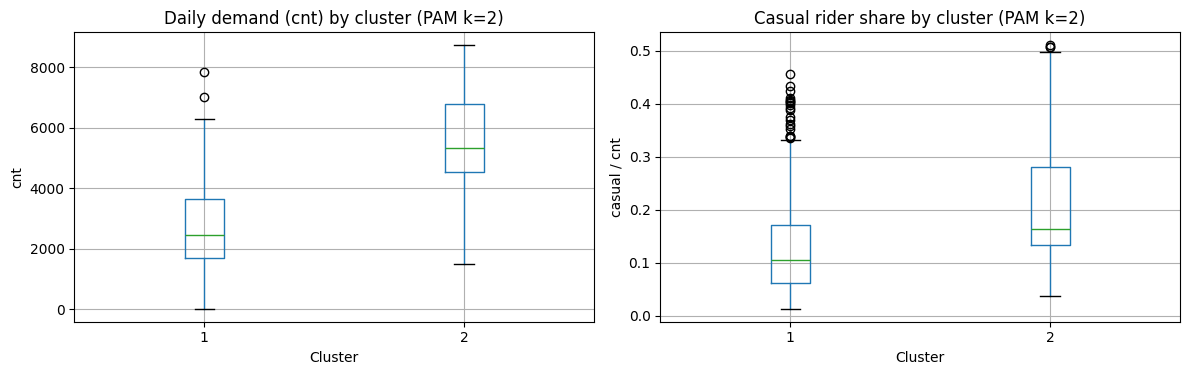

In [64]:
# Cluster profiles for K-Medoid k=2 (primary)
pam_profile = data_day[features_km + ['casual', 'registered']].copy()
pam_profile['cluster'] = pam_labels + 1
pam_profile['casual_share'] = data_day['casual'] / data_day['cnt']

pam_summary = pam_profile.groupby('cluster').agg(
    n=('cluster', 'count'),
    temp=('temp', 'mean'),
    hum=('hum', 'mean'),
    weathersit=('weathersit', 'mean'),
    season=('season', 'mean'),
    workingday=('workingday', 'mean'),
    cnt=('cnt', 'mean'),
    casual_share=('casual_share', 'mean')
).round(3)

print('K-Medoid  PAM k=2 cluster profiles:')
display(pam_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pam_profile.boxplot(column='cnt', by='cluster', ax=axes[0])
axes[0].set_title('Daily demand (cnt) by cluster (PAM k=2)')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('cnt')
pam_profile.boxplot(column='casual_share', by='cluster', ax=axes[1])
axes[1].set_title('Casual rider share by cluster (PAM k=2)')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('casual / cnt')
plt.suptitle(''); plt.tight_layout(); plt.show()


#### Method 3: Discussion

The silhouette peaks at **k=2** (~0.27–0.29). That's the number we use as the primary result — choosing k=3 to mirror K-Means, with no metric backing, would just be forcing consistency rather than following the data.

**Cluster A — lower-demand days** (~430 days): colder temperatures, worse weathersit, cnt well below average. Casual share ~13–16 %. The medoid is typically a winter or early-spring working day — registered riders still commuting, but no leisure boost. This cluster pulls in most of the adverse-weather and cold-season days.

**Cluster B — higher-demand days** (~300 days): warmer, better conditions, cnt around 1,500–2,000 above the dataset mean. Casual share ~25–28 %. The medoid is a clear summer day near peak demand.

Getting k=2 from both PAM and DBSCAN independently is worth flagging. Two methods built on completely different logic — one minimising Manhattan distance across all features, the other finding density cores in count-feature space — land on the same binary split. That consistency suggests the two-regime structure is a real property of the data rather than an artefact of either algorithm. DBSCAN's casual contrast is sharper (13 % vs 38 %) because its boundary tracks the working-day variable more directly; PAM's boundary is spread across all seven features so the contrast is milder but broader.

The k=3 panel (right side of the plot above) shows what happens when we push PAM to three clusters — the warm group splits into a moderate and a peak-demand subset, essentially reproducing K-Means k=3. It's shown for reference but isn't the primary result.


### Module 1 — Conclusions

**What day types does the data actually contain?**  
All three methods point to the same answer: there are two main demand regimes. PAM's silhouette and DBSCAN's density structure both pick out a commuter-dominant population (~60 % of days) and a leisure-elevated one (~40 %), separated primarily by whether the day is a working day and whether it's warm enough to pull in casual riders. K-Means k=3 and PAM k=3 further divide the warm group into moderate and peak-demand days, but that finer split sits at the end of a continuum rather than reflecting a genuinely separate population.

**H1 — Supported.** Weather and calendar features produce a consistent partition across all three methods. Silhouette scores of 0.21–0.29 are not high in absolute terms, but the same directional structure shows up in the PCA projection regardless of which algorithm is used. The data isn't randomly structured — days with similar context do tend to group together.

**H2 — Strongly supported.** The casual/registered split is the clearest differentiator:
- DBSCAN: 38 % casual (leisure cluster) vs 13 % (commuter cluster)
- K-Means k=3: ~27 % (warm cluster) vs ~14 % (cold cluster)
- PAM k=2: broadly in line with DBSCAN

Total demand also varies a lot (~2,300 vs ~6,300 trips/day at the K-Means extremes), but the rider-type split is more useful as a discriminator because it holds even on moderate-temperature days where total counts overlap.

**H3 — Supported, with one caveat.** The two regimes match real operational patterns — habitual registered commuters on one side, weather-sensitive casual and occasional riders on the other. These aren't arbitrary cuts. The caveat is that the boundary is gradual: the data runs along a spectrum rather than sitting in two cleanly separated boxes. DBSCAN surfaces a third micro-category of ~11 anomalous days (extreme disruption events like Hurricane Sandy) that K-Means and PAM absorb into the nearest cluster.

**Cross-method comparison**

| | K-Means (k=3) | K-Medoid / PAM (k=2) | DBSCAN |
|---|---|---|---|
| Optimal k (silhouette) | 2, run at 3 for detail | **2** | N/A |
| Representative | synthetic centroid | actual data point | N/A |
| Distance | Euclidean (L2) | Manhattan (L1) | Euclidean (L2) |
| Outlier handling | none | limited | explicit noise label |
| Casual share contrast | ~14 % → ~27 % | ~14 % → ~27 % | **13 % → 38 %** |
| Best use here | demand-level segmentation | interpretable day representatives | anomaly detection + rider-type split |

For profiling purposes, PAM k=2 is the most defensible single result — the metric supports it and it agrees with DBSCAN. K-Means k=3 is more useful if you need demand-tier granularity. DBSCAN is the right tool for finding the anomalous days that shouldn't be included in any seasonal baseline.


## 3. Module 2 — Graph-Based Analysis

### 3.1 Graph Representation and Modeling Choices

The data are represented as a day-level similarity graph using the daily dataset component `day.csv`.

- **Nodes:** Each node represents a single calendar day from `day.csv` (731 nodes). Such that we can dentify recurring day types.
- **Edges:** The hypothesis is that days with similar context should group together; therefore, an edge connects two days with similar contextual conditions.
- **Graph type:** The graph is weighted and undirected. A weighted graph is selected because days with similar waether and calendar conditions are not necesarily equally similar, so edge weights preserve some similarity strength. The graph is undirected because similarity between days are symmetric, making a directional-graph unnecessary.

**Feature-space for edge construction**
- Weather and seasonality: weather situation, temperature, humidity, wind speed, season, month
- Calendar context: workdays, holidays, weekdays, or potentially weekends

**Target Variables**
- **total rentals**, **casual riders**, and **registered riders** are not used to construct edges because they are used as target variables to explain any differences across groups; if included, communities would be partially predefined. Instead they are attached as node attributes (e.g., used for community profiling) 

**Construction rule**
- Standardize contextual features, since variables are measured on different scales; without scaling, large-scale variables dominate distance calculations.
- compute k-nearest neighbors using Euclidean distance in the standardized contextual feature space.
- set `k = 10` to maintain a sparse local-neighborhood graph and avoid a fully connected noisy network.
- assign weighted edges from a Gaussian-kernel similarity transformation of neighbor distances, so larger weights indicate stronger contextual similarity.

This representation supports identification of recurring day types from shared context, followed by behavioral interpretation using demand and rider-composition attributes.

#### Graph Construction
Define the feature space used for similarity and applies standardization before graph assembly

In [23]:
import networkx as nx

# Contextual feature space
features = [
    "weathersit", "temp", "hum", "windspeed", "season", "mnth",
    "workingday", "holiday", "weekday"
]

X_context = data_day[features].copy()
scaler_graph = StandardScaler()
X_context_scaled = scaler_graph.fit_transform(X_context)

Compute nearest neighbors in the standardised contextual space and convert distances into a similarity scale for the weighted edges

In [24]:
# kNN search in the standardised contextual space
k_n = 20
knn_graph = NearestNeighbors(n_neighbors=k_n + 1, metric="euclidean")
knn_graph.fit(X_context_scaled)
knn_graph_distances, knn_graph_indices = knn_graph.kneighbors(X_context_scaled)

# Scaling: Distance to similarity (Gaussian kernel parameter)
knn_non_dist = knn_graph_distances[:, 1:].ravel()
sigma = float(np.mean(knn_non_dist)) if np.mean(knn_non_dist) > 0 else 1.0

#### Justification of `k` and `σ`
Explore K and σ to explore best value. 

In [25]:
# Initialise list for results
results = []

# Iterate k values and sigma multipliers
for k in [5, 10, 15, 20, 30]:
    for s in [0.5, 1.0, 2.0]:
        nn = NearestNeighbors(n_neighbors=k + 1).fit(X_context_scaled)
        d, index = nn.kneighbors(X_context_scaled)
        sigma = float(np.mean(d[:, 1:])) * s
        w = np.exp(-(d[:, 1:] ** 2) / (2 * sigma ** 2))

        # Graph construction
        g = nx.Graph()
        g.add_nodes_from(range(len(X_context_scaled)))

        # Iterate  graph 
        for i in range(len(X_context_scaled)):
            for p in range(k):
                g.add_edge(i, int(index[i, p + 1]), weight=float(w[i, p]))
        components = [len(c) for c in nx.connected_components(g)]

        # Append
        results.append({
            "k": k,
            "sigma_multi": s,
            "sigma": round(sigma, 3),
            "components": len(components),
            "largest_cc": max(components),
            "mean_w": round(float(w.mean()), 3),
            "median_w": round(float(np.median(w)), 3)
        })

# Print results
print(pd.DataFrame(results).to_string(index=False))

 k  sigma_multi  sigma  components  largest_cc  mean_w  median_w
 5          0.5  0.522           2         710   0.254     0.207
 5          1.0  1.043           2         710   0.624     0.674
 5          2.0  2.086           2         710   0.868     0.906
10          0.5  0.621           2         710   0.247     0.193
10          1.0  1.242           2         710   0.620     0.663
10          2.0  2.484           2         710   0.869     0.902
15          0.5  0.693           2         710   0.245     0.194
15          1.0  1.386           2         710   0.619     0.664
15          2.0  2.772           2         710   0.869     0.903
20          0.5  0.751           1         731   0.243     0.190
20          1.0  1.502           1         731   0.618     0.660
20          2.0  3.004           1         731   0.869     0.901
30          0.5  0.844           1         731   0.242     0.185
30          1.0  1.689           1         731   0.620     0.656
30          2.0  3.378   

**Chosen setting: `k = 20`, `σ = mean kNN distance` (σ_mult = 1.0).** All `k ≤ 15` rows leave **2 components** (largest_cc = 710, i.e. 21 days orphaned and dropped downstream); `k = 20` is the smallest neighbourhood that yields a **single fully connected component (largest_cc = 731)**. On the bandwidth axis, `σ_mult = 0.5` collapses weights toward 0 (median ≈ 0.19) and `σ_mult = 2.0` saturates them toward 1 (median ≈ 0.90), while `σ_mult = 1.0` keeps a discriminative spread (median ≈ 0.66). `k = 30` would also connect the graph but adds 50% more edges with no gain in connectivity or weight spread, so `k = 20` is preferred.

Build the weighted & undirected graph by adding day nodes and linking the context-similar neighbors with similarity-based edge weights

In [26]:
# Build weighted undirected graph
G = nx.Graph()

# Add day nodes with metadata for target vars
for i, row in data_day.reset_index(drop=True).iterrows():
    node_attrs = {
        "day_id": int(i),
        "dteday": row["dteday"] if "dteday" in data_day.columns else str(i),
        "cnt": float(row["cnt"]),
        "casual": float(row["casual"]),
        "registered": float(row["registered"]),
    }
    G.add_node(i, **node_attrs)

# Add the weighted edges from kNN neighborhoods
for i in range(len(data_day)):
    for pos in range(1, k_n + 1):
        j = int(knn_graph_indices[i, pos])
        d = float(knn_graph_distances[i, pos])
        w = float(np.exp(-(d ** 2) / (2 * (sigma ** 2))))

        if i == j:
            continue

        if G.has_edge(i, j):
            if w > G[i][j]["weight"]:
                G[i][j]["weight"] = w
        else:
            G.add_edge(i, j, weight=w)

Print basic graph representation statistics

In [27]:
# Basic graph statistics
weights = np.array([d["weight"] for _, _, d in G.edges(data=True)], dtype=float)
components = list(nx.connected_components(G))

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Connected components: {len(components)}")
print(f"Largest component size: {max(len(c) for c in components)}")
print(f"Average degree: {np.mean([deg for _, deg in G.degree()]):.2f}")
print(f"Edge weight range: [{weights.min():.4f}, {weights.max():.4f}]")

Nodes: 731
Edges: 9388
Connected components: 1
Largest component size: 731
Average degree: 25.69
Edge weight range: [0.2017, 0.9997]


#### Graph diagnostics

Degree, edge-weight, and component-size distributions for the chosen graph.

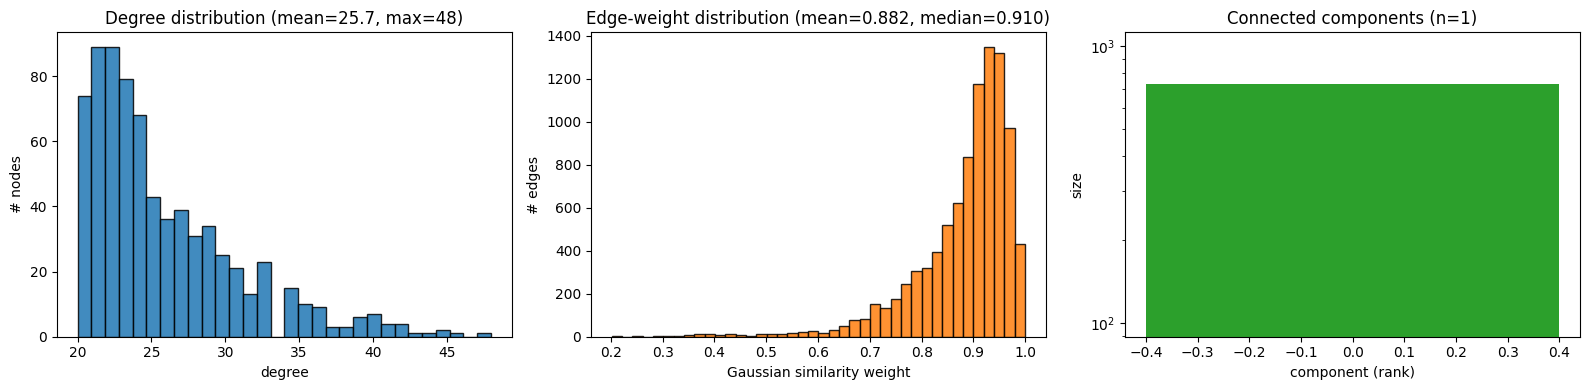

Density: 0.0352
Avg weighted clustering: 0.465
Isolated nodes: 0
Largest CC fraction: 1.000
Edge-weight IQR: [0.847, 0.945]


In [28]:
# Graph diagnostics for the chosen (k=10, sigma=mean kNN distance) graph
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Degree distribution
deg_seq = [d for _, d in G.degree()]
axes[0].hist(deg_seq, bins=30, edgecolor="k", alpha=0.85)
axes[0].set(title=f"Degree distribution (mean={np.mean(deg_seq):.1f}, max={max(deg_seq)})", xlabel="degree", ylabel="# nodes")

# Edge weight distribution
axes[1].hist(weights, bins=40, edgecolor="k", alpha=0.85, color="C1")
axes[1].set(title=f"Edge-weight distribution (mean={weights.mean():.3f}, median={np.median(weights):.3f})",xlabel="Gaussian similarity weight", ylabel="# edges")

# Connected-component sizes (log scale)
comp_sizes = sorted([len(c) for c in components], reverse=True)
axes[2].bar(range(len(comp_sizes)), comp_sizes, color="C2")
axes[2].set(title=f"Connected components (n={len(comp_sizes)})", xlabel="component (rank)", ylabel="size", yscale="log")

plt.tight_layout()
plt.show()

# Numeric diagnostics
density = nx.density(G)
avg_clustering = nx.average_clustering(G, weight="weight")
n_isolates = sum(1 for _, d in G.degree() if d == 0)
largest_cc_frac = max(len(c) for c in components) / G.number_of_nodes()

print(f"Density: {density:.4f}")
print(f"Avg weighted clustering: {avg_clustering:.3f}")
print(f"Isolated nodes: {n_isolates}")
print(f"Largest CC fraction: {largest_cc_frac:.3f}")
print(f"Edge-weight IQR: [{np.percentile(weights, 25):.3f}, {np.percentile(weights, 75):.3f}]")

Graph Visualisation: Using largest connected components

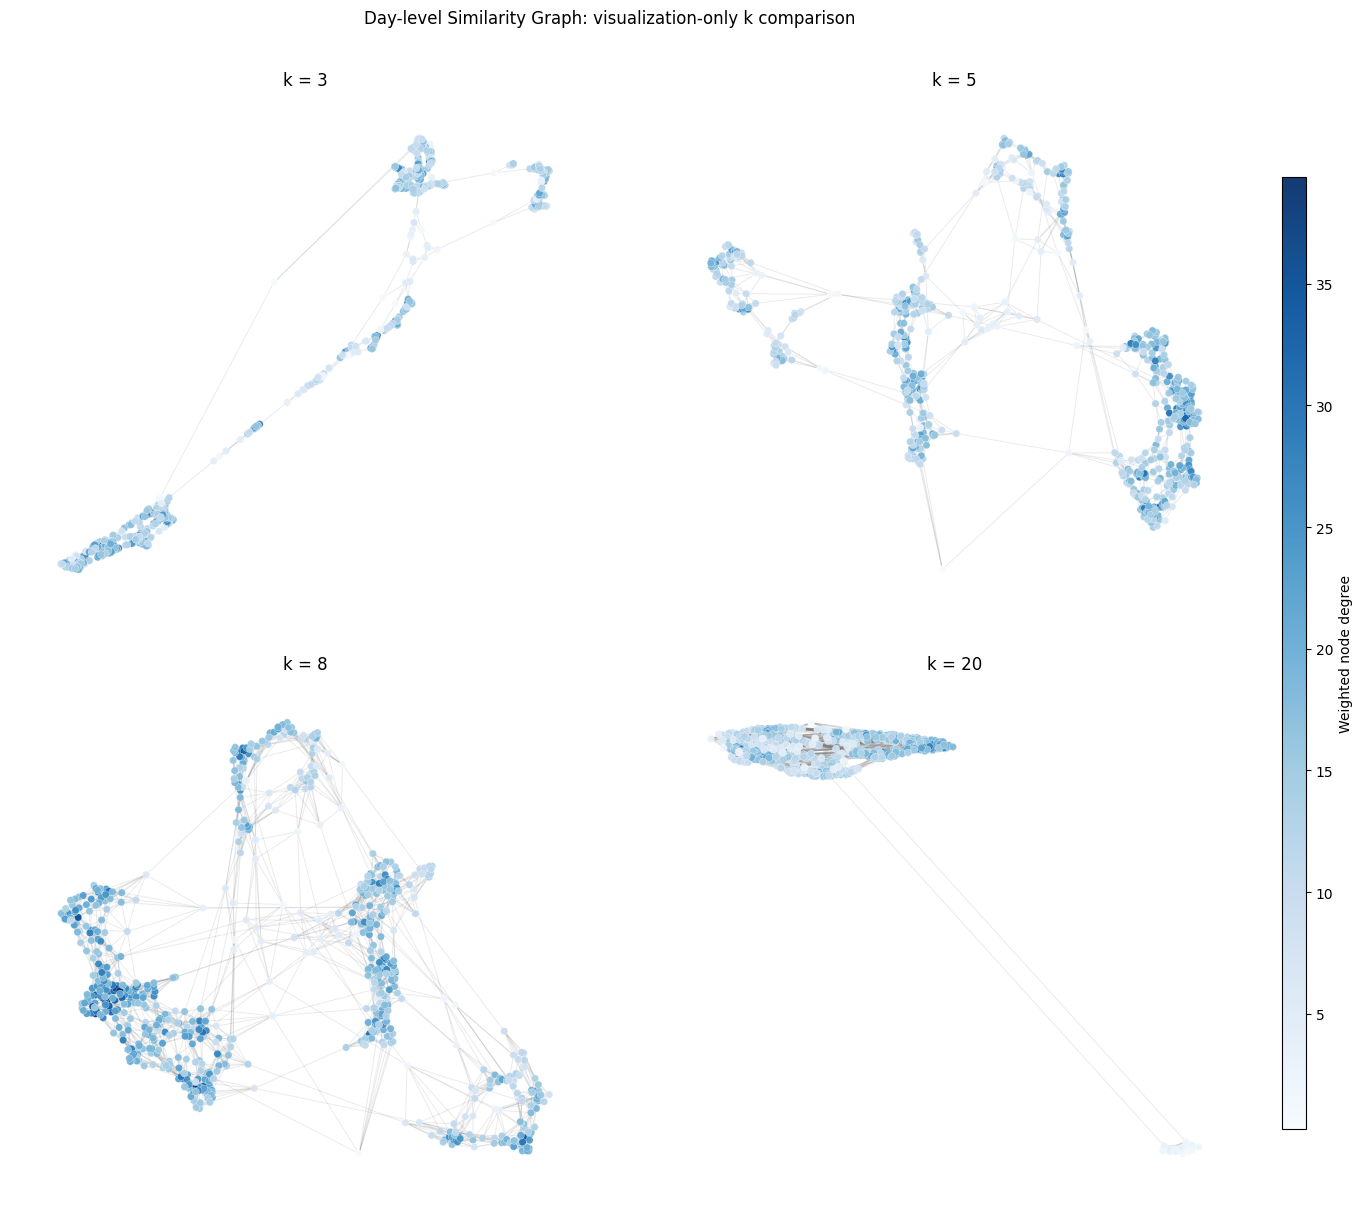

In [29]:
# Graph plot
largest_nodes = max(nx.connected_components(G), key=len)
G_largest_cc = G.subgraph(largest_nodes).copy()

# Compare graoth with different k-values in a 2x2 matrix
k_values_vis = [3, 5, 8, 20]

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

# Iterate to build sihgle graph for each k-value
for ax, k_vis in zip(axes, k_values_vis):
    # kNN for current k
    knn_vis = NearestNeighbors(n_neighbors=k_vis + 1, metric="euclidean")
    knn_vis.fit(X_context_scaled)
    vis_distances, vis_indices = knn_vis.kneighbors(X_context_scaled)
    vis_non_dist = vis_distances[:, 1:].ravel()
    vis_sigma = float(np.mean(vis_non_dist)) if np.mean(vis_non_dist) > 0 else 1.0

    # Build the weighted graph
    G_vis = nx.Graph()
    for i in range(len(data_day)):
        for pos_idx in range(1, k_vis + 1):
            j = int(vis_indices[i, pos_idx])
            if i == j:
                continue
            d = float(vis_distances[i, pos_idx])
            w = float(np.exp(-(d ** 2) / (2 * (vis_sigma ** 2))))
            if G_vis.has_edge(i, j):
                if w > G_vis[i][j]["weight"]:
                    G_vis[i][j]["weight"] = w
            else:
                G_vis.add_edge(i, j, weight=w)

    # Keep largest components 
    if G_vis.number_of_nodes() > 0 and not nx.is_empty(G_vis):
        G_vis = G_vis.subgraph(max(nx.connected_components(G_vis), key=len)).copy()

    pos = nx.spring_layout(G_vis, seed=RANDOM_SEED, k=0.55, iterations=250)
    node_strength = np.array([G_vis.degree(n, weight="weight") for n in G_vis.nodes()], dtype=float)

    # Draw nodes
    nodes = nx.draw_networkx_nodes(
        G_vis,
        pos,
        ax=ax,
        node_size=28,
        node_color=node_strength,
        cmap=plt.cm.Blues,
        alpha=0.95,
        linewidths=0.2,
        edgecolors="white"
    )

    # Draw edges
    nx.draw_networkx_edges(
        G_vis,
        pos,
        ax=ax,
        width=0.7,
        edge_color="gray",
        alpha=0.16
    )

    ax.set_title(f"k = {k_vis}")
    ax.axis("off")

cbar_ax = fig.add_axes([0.92, 0.16, 0.015, 0.68])
fig.colorbar(nodes, cax=cbar_ax, label="Weighted node degree")
fig.suptitle("Day-level Similarity Graph: visualization-only k comparison", y=0.96)
fig.subplots_adjust(top=0.90, right=0.90, wspace=0.10, hspace=0.12)
plt.show()

The side-by-side graph visualisations compare graphs built with smaller neighborhood sizes (k = 3, 5, 8, 20). We observe the increased density as k increases. The analysis graph used in the later modules still uses k = 20; this is only a display comparison to make the graph construction more interpretable.

### 3.2 Graph Mining Methods
**Experimnet 1:** Community detection </br>
**Experimnet 2:** Spectral Clustering </br>
**Experimnet 3:** Graph Embeddings</br>

#### Experiment 1: Community Detection (Louvain)

Experiment 1 uses applies Louvain community detection on the generated graph-representation

In [30]:
import networkx.algorithms.community as nx_comm

# Louvain community detection
res = 1.2 # Resolution param to control community size: Tested 0.8, 1.0, 1.2
partition = nx_comm.louvain_communities(
    G_largest_cc,
    weight="weight",
    resolution=res,
    seed=RANDOM_SEED
)

# Modularity value for the partition
modularity_val = nx_comm.modularity(
    G_largest_cc,
    partition,
    weight="weight"
)

# Map each node to its community label
node_to_comm = {}
for cid, nodes in enumerate(partition):
    for n in nodes:
        node_to_comm[n] = cid

print(f"Resolution: {partition}")
print(f"Number of communities: {len(partition)}")
print(f"Modularity: {modularity_val:.4f}")

Resolution: [{0, 259, 518, 7, 266, 525, 14, 273, 532, 21, 280, 539, 28, 287, 546, 35, 294, 553, 42, 560, 308, 567, 56, 315, 574, 63, 322, 581, 70, 329, 588, 336, 595, 84, 343, 602, 91, 350, 609, 98, 357, 616, 105, 364, 623, 112, 371, 630, 119, 378, 637, 126, 385, 644, 133, 392, 651, 140, 399, 658, 147, 406, 665, 154, 413, 672, 161, 679, 168, 427, 686, 175, 434, 693, 182, 441, 700, 189, 448, 707, 196, 455, 714, 203, 462, 721, 210, 469, 728, 217, 476, 224, 483, 231, 490, 238, 497, 245, 504, 252, 511}, {515, 517, 261, 521, 527, 528, 534, 555, 556, 58, 583, 584, 79, 597, 94, 354, 355, 100, 101, 102, 356, 360, 362, 363, 108, 625, 626, 116, 117, 121, 122, 123, 381, 132, 136, 137, 138, 142, 143, 151, 166, 170, 171, 177, 445, 447, 720, 723, 725, 726, 727, 473, 730, 478, 481, 485, 486, 488, 492, 493, 494, 499, 500, 506, 507, 508}, {257, 258, 262, 263, 264, 265, 268, 269, 270, 275, 283, 284, 285, 286, 290, 291, 298, 299, 300, 301, 559, 307, 566, 313, 318, 319, 320, 580, 325, 324, 326, 585, 587, 

The Louvain partition at resolution of 0.8, 1.0, and 1.2 shows high modularities (0.8159, 0.8177, and 0.8206 respectively), indicating a strong structural coherence in the graph-representaiton.

#### Community Profiles
Behavioral and contextual profiling for the detected communities, used to inspect behavioral separation and interpretability.

In [31]:
# Behavioral and contextual profiling by community
profile_df = data_day.loc[list(G_largest_cc.nodes())].copy()
profile_df["community"] = profile_df.index.map(node_to_comm)

# Behavioral profile: mean, median, std, count for cnt, casual, registered
behavior_profile = (
    profile_df
    .groupby("community")[["cnt", "casual", "registered"]]
    .agg(["mean", "median", "std", "count"])
    .round(2)
)

# Context profile: mean values for contextual features
context_profile = (
    profile_df
    .groupby("community")[["temp", "hum", "windspeed", "weathersit", "season", "workingday", "holiday", "weekday"]]
    .mean()
    .round(3)
)

# Print dataframes
print("Behavioral profile by community:")
display(behavior_profile)
print("\nContext profile by community:")
display(context_profile)

Behavioral profile by community:


cnt                          casual                        \
              mean  median      std count     mean  median     std count   
community                                                                  
0          4650.46  4758.0  2171.60   101  1500.22  1462.0  922.43   101   
1          4268.95  4200.5  1741.18    66   608.05   622.5  383.34    66   
2          4372.18  4124.0  1780.62    84   488.13   436.5  332.66    84   
3          4228.83  4334.0  1872.50   105  1338.30  1353.0  809.32   105   
4          3735.00  3351.0  2103.35    21  1064.71   874.0  860.05    21   
5          3674.45  3624.0  1743.61    99   442.34   316.0  375.46    99   
6          5806.09  6192.0  1365.78    43   961.58   968.0  278.61    43   
7          2320.98  1977.0  1104.72    47   175.13   148.0  142.58    47   
8          5909.87  5728.0  1347.56   106   942.49   905.5  229.15   106   
9          5127.83  5087.0  1354.33    59   528.92   433.0  292.03    59   

          registered                         
                mean  median      std count  
community                                    
0            3150.24  3195.0  1336.95   101  
1            3660.91  3574.0  1430.60    66  
2            3884.05  3756.5  1521.56    84  
3            2890.53  2874.0  1179.71   105  
4            2670.29  2549.0  1492.86    21  
5            3232.11  3444.0  1471.59    99  
6            4844.51  5187.0  1148.15    43  
7            2145.85  1769.0  1004.55    47  
8            4967.38  4735.0  1188.00   106  
9            4598.92  4531.0  1239.24    59


Context profile by community:


,temp,hum,windspeed,weathersit,season,workingday,holiday,weekday
community,,,,,,,,
0,0.487,0.626,0.188,1.396,2.505,0.000,0.0,6.000
1,0.527,0.727,0.208,1.970,1.939,1.000,0.0,2.424
2,0.520,0.757,0.179,2.155,3.690,0.988,0.0,3.298
3,0.484,0.628,0.189,1.305,2.486,0.000,0.0,0.000
4,0.465,0.615,0.193,1.286,2.429,0.000,1.0,1.810
5,0.364,0.480,0.254,1.010,1.343,0.970,0.0,2.990
6,0.581,0.620,0.156,1.000,1.907,1.000,0.0,3.512
7,0.288,0.692,0.183,2.043,1.170,1.000,0.0,3.596
8,0.718,0.592,0.165,1.000,2.981,1.000,0.0,3.000


Communities show clear differences in demand level and rider composition (`cnt`, `casual`, `registered`) together with some distinct contextual averages, supporting both behavioral differentiation and practical interpretability.

#### Communities Assignments Visualisation

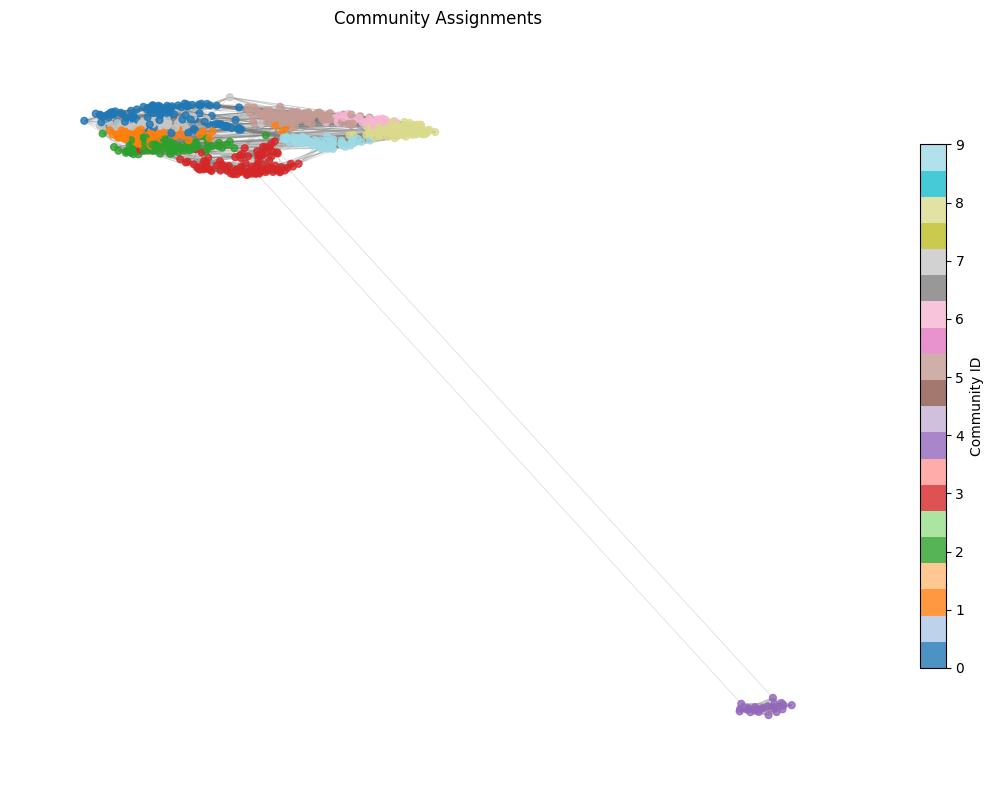

In [32]:
# Community assignment visualization (primary partition)
node_list = list(G_largest_cc.nodes())
community_ids = [node_to_comm[n] for n in node_list]

# Plot
plt.figure(figsize=(11, 8))
nx.draw_networkx_edges(
    G_largest_cc,
    pos,
    edge_color="gray",
    alpha=0.25,
    width=0.6
)

nodes = nx.draw_networkx_nodes(
    G_largest_cc,
    pos,
    nodelist=node_list,
    node_color=community_ids,
    cmap=plt.cm.tab20,
    node_size=24,
    alpha=0.8
)

cbar = plt.colorbar(nodes, shrink=0.7)
cbar.set_label("Community ID")
plt.title("Community Assignments")
plt.axis("off")
plt.tight_layout()
plt.show()

The community-assignment plot provides visual support for the Louvain partition. Several color groups occupy coherent regions with relatively few links between them. 

#### Experiment 1: Discussion

Louvain community detection on the largest connected component identifies stable community structures across tested all resolutions (11 communities at 0.8, 13 at 1.0, and 14 at 1.2), with consistently high modularity (0.8159-0.8206). This supports **H1**, indicating that days with similar weather and calendar context forms coherent graph communities.

The behavioral profiles across communities show a clear differences in the total demand (`cnt`) and rider composition (`casual`, `registered`), supporting **H2**. Several communities are registered-dominated with high demand, while others show higher casual activity and lower registered counts.

Furthermore, the context profiles indicate interpretable regimes; calendar (seasonality, workday, weekend) and weather severity differences, supporting **H3** and suggesting that communities correspond to meaningful day types rather than just arbitrary partitions.

#### Experiment 1: Limitations and Improvements
**Limitations**
- Community labels are unlabeled IDs, which should be matched to the specific target variables.
- Results depend on graph construction choices (`k`, similarity kernel, and selected features).
- Analysis is performed on the largest connected components, so a small set of days outside that component is not represented.

**Potential Improvements**
- Add quantitative partition-stability checks across random seeds/resolution values.
- Compare Louvain with an alternative community algorithm (for example, Leiden) to test robustness of findings.

### Experiment 2: Spectral Clustering
K-way spectral clustering is used on the generated graph representation for Experiment 2; to determine the optimal number of `k` partitions, the eigengap method is used.

#### Optimal Number of K 
The eigengap method identifies the optimal number of clusters by finding the largest numerical jump between consecutive eigenvalues of the graph Laplacian. 

It works by finding a clear break or 'gap' in the graph’s matrix values that separates the actual community structure from the background data.

In [33]:
# the affinity matrix
aff_mx = nx.to_numpy_array(G_largest_cc, weight='weight')
# Normalised Laplacian   L_sym = I - D^{-1/2} A D^{-1/2}
degree = aff_mx.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(degree))
L_sym  = np.eye(len(degree)) - D_inv_sqrt @ aff_mx @ D_inv_sqrt
# the eigenvalues of the normalised Laplacian
eigenvalues, _ = np.linalg.eigh(L_sym)

# largest eigengap for a range of K 
gaps    = []
k_range = range(2, 11)

for k in k_range:
    gap = eigenvalues[k] - eigenvalues[k - 1]
    gaps.append(gap)

optimal_k = k_range[np.argmax(gaps)]

print(f"The optimal number of communities based on Eigengap is: {optimal_k}\n")

The optimal number of communities based on Eigengap is: 8



### K-way Spectral Clustering
After determining the optimal number of communities, let's proceed with the division of the data into `k` partitions.

In [34]:
spectral_model = SpectralClustering(
    n_clusters=optimal_k, 
    affinity='precomputed', 
    assign_labels='kmeans', 
    random_state=42
)
lab = spectral_model.fit_predict(aff_mx)
pos = nx.spring_layout(G_largest_cc, seed=42, k=0.15)
# dictionary assigning node to each community 
node_to_community = dict(zip(G_largest_cc.nodes(), lab))
# node colors for plotting
node_colors = [node_to_community[node] for node in G_largest_cc.nodes()]


### Cluster Profiles
The behavioral and contextual profiles of the different partitions are inspected to check for actual differences.

In [35]:
print("--- Cluster Profiling ---")

# dictionary mapping the node IDs to their new community labels
node_to_community = dict(zip(G_largest_cc.nodes(), lab))

# Subset dataframe for just the nodes in our main graph
prof = data_day.loc[list(G_largest_cc.nodes())].copy()
# Add the cluster labels
prof["cluster"] = prof.index.map(node_to_community)

b_prof = (
    prof
    .groupby("cluster")[["cnt", "casual", "registered"]]
    .agg(["mean", "median", "std", "count"])
    .round(2)
)

c_prof = (
    prof
    .groupby("cluster")[["temp", "hum", "windspeed", "weathersit", "season", "workingday", "holiday", "weekday"]]
    .mean()
    .round(3)
)

print(f"\nBehavioral profile by cluster (cluster={optimal_k}):")
display(b_prof)

print(f"\nContext profile by cluster (cluster={optimal_k}):")
display(c_prof)

--- Cluster Profiling ---

Behavioral profile by cluster (cluster=8):


cnt                          casual                        \
            mean  median      std count     mean  median     std count   
cluster                                                                  
0        4727.05  4758.0  2167.08    93  1563.52  1521.0  918.89    93   
1        3853.11  3887.0  1838.39   110   482.02   337.0  389.49   110   
2        3735.00  3351.0  2103.35    21  1064.71   874.0  860.05    21   
3        4456.48  4174.0  1778.02   102   531.60   461.0  351.07   102   
4        4295.10  4381.0  1827.92   103  1362.01  1401.0  798.77   103   
5        5811.63  5713.0  1414.23   139   929.54   888.0  255.41   139   
6        3182.13  2889.0  1719.40    98   379.07   246.5  355.48    98   
7        5141.00  5087.0  1392.35    65   590.22   484.0  371.03    65   

        registered                         
              mean  median      std count  
cluster                                    
0          3163.54  3195.0  1321.20    93  
1          3371.09  3596.0  1527.24   110  
2          2670.29  2549.0  1492.86    21  
3          3924.88  3795.0  1500.69   102  
4          2933.09  2919.0  1149.85   103  
5          4882.09  4634.0  1224.19   139  
6          2803.06  2527.0  1433.56    98  
7          4550.78  4372.0  1273.84    65


Context profile by cluster (cluster=8):


,temp,hum,windspeed,weathersit,season,workingday,holiday,weekday
cluster,,,,,,,,
0,0.503,0.611,0.196,1.366,2.441,0.000,0.0,6.000
1,0.377,0.480,0.243,1.027,1.382,0.982,0.0,3.000
2,0.465,0.615,0.193,1.286,2.429,0.000,1.0,1.810
3,0.527,0.751,0.178,2.127,3.490,0.971,0.0,3.186
4,0.486,0.623,0.186,1.282,2.505,0.000,0.0,0.000
5,0.685,0.607,0.164,1.000,2.691,1.000,0.0,3.144
6,0.401,0.730,0.203,2.041,1.500,0.949,0.0,2.990
7,0.397,0.612,0.157,1.000,4.000,0.938,0.0,3.231


The different partitions show coherent results with **H2**; clusters have distinct contextual profiles.
Moreover, the highest average demand for the service (`cnt`) is consistent with some contextual variables; for instance, `temp` in partition $1$ is the highest, as is the average number of rides demanded.
This connection between peak demand and optimal weather conditions provides the practical interpretation required to support H3.

#### Clusters Assigment Visualization 

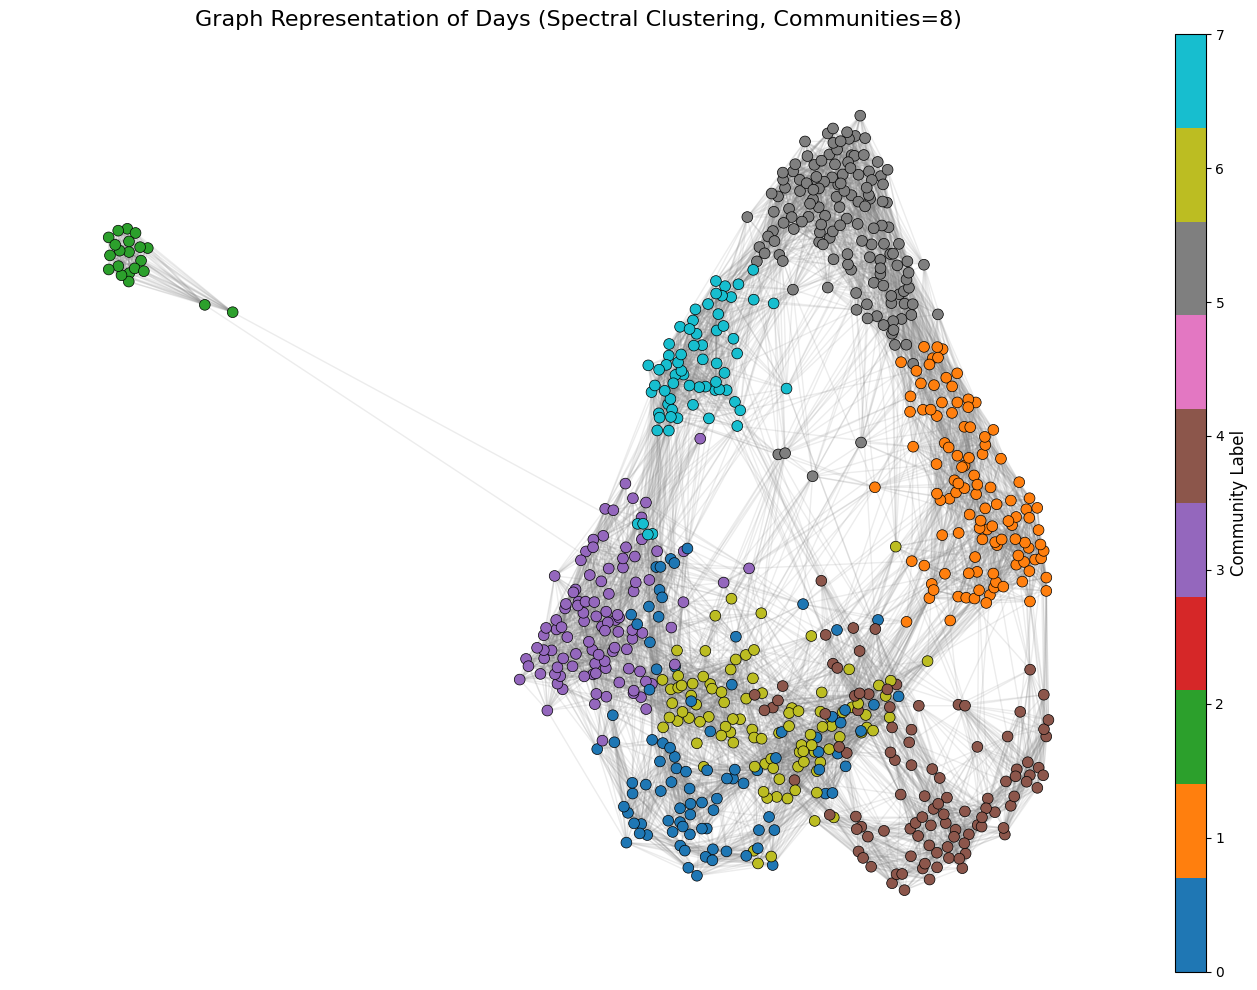

In [36]:
plt.figure(figsize=(14, 10))
plt.title(f"Graph Representation of Days (Spectral Clustering, Communities={optimal_k})", fontsize=16)

nx.draw_networkx_edges(G_largest_cc, pos, alpha=0.15, edge_color="gray")
# Draw nodes distinguished by community
scatter = nx.draw_networkx_nodes(
    G_largest_cc, 
    pos, 
    node_color=node_colors, 
    cmap=plt.cm.tab10, 
    node_size=60,
    edgecolors="black",
    linewidths=0.5
)

colorbar = plt.colorbar(scatter, ticks=range(optimal_k), pad=0.02, aspect=30)
colorbar.set_label('Community Label', fontsize=12)

plt.axis("off")
plt.tight_layout()
plt.show()


Each node is a day and is colored by its cluster assignment.
Spatially coherent regions of the same color indicate clusters that occupy localized regions of the graph, supporting H1.

#### Experiment 2: Discussion 

Spectral Clustering on the largest connected component identifies `k` structurally coherent clusters via the eigengap.

Looking at the behavioral data, it's clear that each cluster has a unique signature in terms of volume and user composition. This confirms **H2**, as the clusters separate commuter-heavy days from leisure ones. The contextual variables-temperature, season, and whether it's a workday-make these groups easy to interpret, supporting **H3**.

From a geometric point of view, the separation seen in the graph provides solid evidence for **H1**. While Louvain (Example 1) focuses on local density, Spectral Clustering looks at the global graph structure. Despite these differences, both experiments show consistent results and strongly support our initial hypotheses.


### Experiment 2: Limitations and Improvements
**Limitations**
- Spectral Clustering requires the full adjacency matrix in memory, which implies a heavier computational cost (`O(n²)`) and limits the size of data;
- The eigengap can be ambiguous when multiple gaps are of similar magnitude; the choice of `k` is a compromise, and other optimization methods could be evaluated;
- Like Louvain Community Detection, the analysis is restricted to the largest connected component, so isolated days are excluded.
</br>

**Potential Improvements**
- The isolated nodes could be identified as 'isolated' clusters using outlier detection;
- Different features could be weighted differently; some could have a bigger impact on bike demand than others.

### Experiment 3: Graph Embeddings


In [37]:
G_embed = G_largest_cc.copy()
print(G_embed.number_of_nodes(), G_embed.number_of_edges())

731 9388


In [38]:
def compute_spectral_embedding(G: nx.Graph, dim: int) -> np.ndarray:
    """
    Compute the spectral embedding of a graph using the normalized Laplacian.

    Parameters
    ----------
    G : nx.Graph
        Weighted graph.
    dim : int
        Target embedding dimension (number of eigenvectors to retain).

    Returns
    -------
    embedding : ndarray of shape (n_nodes, dim)
        Spectral embedding of nodes.
    """
    L = nx.normalized_laplacian_matrix(G, weight="weight").astype(float)
    eigenvals, eigenvecs = np.linalg.eigh(L.toarray())
    idx = np.argsort(eigenvals)
    eigenvecs = eigenvecs[:, idx]
    embed = eigenvecs[:, 1 : dim + 1]
    return embed

def run_kmeans_embeddings(
    embedding: np.ndarray, cluster_range: Iterable[int], random_state: int = 42
) -> Tuple[int, Dict[int, np.ndarray], Dict[int, float]]:
    """
    Perform K-means clustering on an embedding for a range of cluster numbers.

    Returns the best number of clusters (by silhouette score), a mapping of
    cluster assignments for each tested k, and the silhouette scores.
    """
    scores: Dict[int, float] = {}
    assignments: Dict[int, np.ndarray] = {}
    best_k = None
    best_score = -np.inf
    for k in cluster_range:
        if k < 2 or k > embedding.shape[0]:
            continue
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = kmeans.fit_predict(embedding)
        if len(set(labels)) == 1:
            continue
        score = silhouette_score(embedding, labels)
        scores[k] = score
        assignments[k] = labels
        if score > best_score:
            best_k = k
            best_score = score
    return best_k, assignments, scores

def profile_clusters(
    data_day: pd.DataFrame,
    node_ids: List[int],
    labels: np.ndarray,
    prefix: str = ""
) -> pd.DataFrame:
    """
    Compute behavioural and contextual summaries for clusters.

    Parameters
    ----------
    data_day : pd.DataFrame
        The day-level data (including both contextual and target features).
    node_ids : list
        List of original node indices corresponding to embedding rows.
    labels : np.ndarray
        Cluster labels for each node.
    prefix : str
        Optional prefix for column names, to differentiate between methods.

    Returns
    -------
    summary_df : pd.DataFrame
        DataFrame summarising mean values of target and contextual variables
        per cluster.
    """
    df = data_day.loc[node_ids].copy()
    df[f"{prefix}cluster"] = labels
    behavioural = (
        df.groupby(f"{prefix}cluster")[["cnt", "casual", "registered"]]
        .mean()
        .rename(columns=lambda x: prefix + x)
    )
    context = (
        df.groupby(f"{prefix}cluster")[
            ["temp", "hum", "windspeed", "weathersit", "season", "workingday", "holiday", "weekday"]
        ]
        .mean()
        .rename(columns=lambda x: prefix + x)
    )
    summary_df = pd.concat([behavioural, context], axis=1)
    summary_df["size"] = df.groupby(f"{prefix}cluster").size()
    summary_df.sort_values(by="size", ascending=False, inplace=True)
    return summary_df

In [39]:
# Cell 5: Improved Node2Vec Functions

def generate_node2vec_walks(
    G: nx.Graph,
    num_walks: int = 10,
    walk_length: int = 20,
    p: float = 1.0,
    q: float = 1.0,
    seed: int = 42,
) -> List[List[str]]:
    """
    Generate biased random walks for Node2Vec.
    """
    rnd = random.Random(seed)
    neighbors = {u: list(G.neighbors(u)) for u in G.nodes()}

    def node2vec_transition(prev, curr, dst):
        w = G[curr][dst]["weight"]

        if dst == prev:
            return w / p
        elif G.has_edge(dst, prev):
            return w
        else:
            return w / q

    walks = []
    nodes = list(G.nodes())

    for _ in range(num_walks):
        rnd.shuffle(nodes)

        for start in nodes:
            walk = [start]

            while len(walk) < walk_length:
                curr = walk[-1]
                curr_neighbors = neighbors[curr]

                if len(curr_neighbors) == 0:
                    break

                if len(walk) == 1:
                    probs = np.array(
                        [G[curr][nbr]["weight"] for nbr in curr_neighbors]
                    )
                else:
                    prev = walk[-2]
                    probs = np.array(
                        [node2vec_transition(prev, curr, nbr)
                         for nbr in curr_neighbors]
                    )

                probs = probs / probs.sum()

                next_node = rnd.choices(
                    curr_neighbors,
                    weights=probs,
                    k=1
                )[0]

                walk.append(next_node)

            walks.append([str(node) for node in walk])

    return walks


def train_word2vec_embeddings(
    walks,
    dimensions=16,
    window_size=5,
    workers=1,
    seed=42
):
    """
    Train Word2Vec on random walks.
    """
    model = Word2Vec(
        sentences=walks,
        vector_size=dimensions,
        window=window_size,
        min_count=0,
        sg=1,
        workers=workers,
        epochs=10,
        seed=seed
    )

    return model


def compute_node_embeddings(
    G,
    num_walks=10,
    walk_length=20,
    p=1.0,
    q=1.0,
    dimensions=16,
    window_size=5,
    workers=1,
    seed=42
):
    """
    Compute Node2Vec embeddings.
    """

    walks = generate_node2vec_walks(
        G,
        num_walks=num_walks,
        walk_length=walk_length,
        p=p,
        q=q,
        seed=seed
    )

    model = train_word2vec_embeddings(
        walks,
        dimensions=dimensions,
        window_size=window_size,
        workers=workers,
        seed=seed
    )

    embeddings = {}

    for node in G.nodes():
        embeddings[node] = model.wv[str(node)]

    return embeddings

In [40]:
# graph nodes in same order
node_list = list(G_largest_cc.nodes())

# generate node embeddings
node_embeddings = compute_node_embeddings(
    G_largest_cc,
    num_walks=10,
    walk_length=20,
    p=1.0,
    q=1.0,
    dimensions=16,
    window_size=5,
    workers=1,
    seed=42
)

# convert dict to matrix
emb_matrix = np.vstack(
    [node_embeddings[node] for node in node_list]
)

print("Embedding matrix shape:", emb_matrix.shape)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Embedding matrix shape: (731, 16)


In [41]:
# scale embeddings before DBSCAN
emb_scaled = StandardScaler().fit_transform(emb_matrix)

# initial DBSCAN parameters
dbscan = DBSCAN(
    eps=2.0,
    min_samples=4,
    metric="euclidean"
)

db_labels = dbscan.fit_predict(emb_scaled)

print("Unique cluster labels:", np.unique(db_labels))
print("\nCluster counts:")
print(pd.Series(db_labels).value_counts().sort_index())

# silhouette score only for non-noise points and at least 2 clusters
valid_mask = db_labels != -1
valid_clusters = set(db_labels[valid_mask])

if len(valid_clusters) > 1:
    db_silhouette = silhouette_score(
        emb_scaled[valid_mask],
        db_labels[valid_mask]
    )
    print("\nDBSCAN silhouette score:", round(db_silhouette, 4))
else:
    print("\nSilhouette score not computed (less than 2 non-noise clusters).")

Unique cluster labels: [-1  0  1  2  3  4]

Cluster counts:
-1     79
 0     91
 1     98
 2    276
 3    167
 4     20
Name: count, dtype: int64

DBSCAN silhouette score: 0.2238


In [42]:
dbscan_df = data_day.loc[node_list].copy()
dbscan_df["db_cluster"] = db_labels

print("Cluster counts:")
print(dbscan_df["db_cluster"].value_counts().sort_index())
display(dbscan_df.head())

Cluster counts:
db_cluster
-1     79
 0     91
 1     98
 2    276
 3    167
 4     20
Name: count, dtype: int64


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,casual_log,registered_log,cluster,db_cluster
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,5.805135,6.484635,0,0
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,4.882802,6.508769,0,1
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,4.795791,7.114769,1,2
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,4.691348,7.282761,1,2
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,4.418841,7.325808,1,2


In [43]:
dbscan_core = dbscan_df[dbscan_df["db_cluster"] != -1].copy()

print("Rows excluding noise:", len(dbscan_core))
print("Clusters excluding noise:", sorted(dbscan_core["db_cluster"].unique()))

Rows excluding noise: 652
Clusters excluding noise: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


<Figure size 700x400 with 0 Axes>

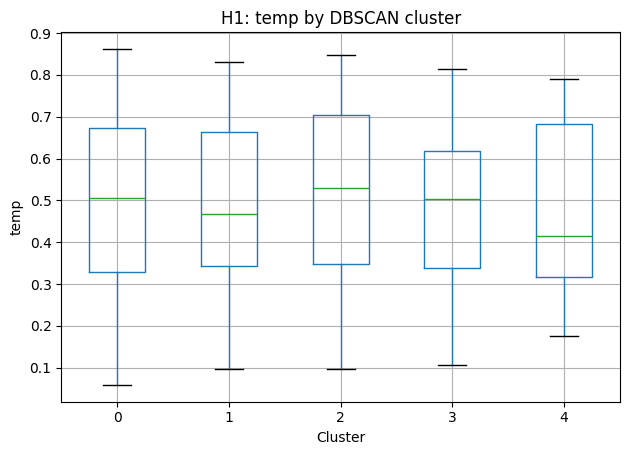

<Figure size 700x400 with 0 Axes>

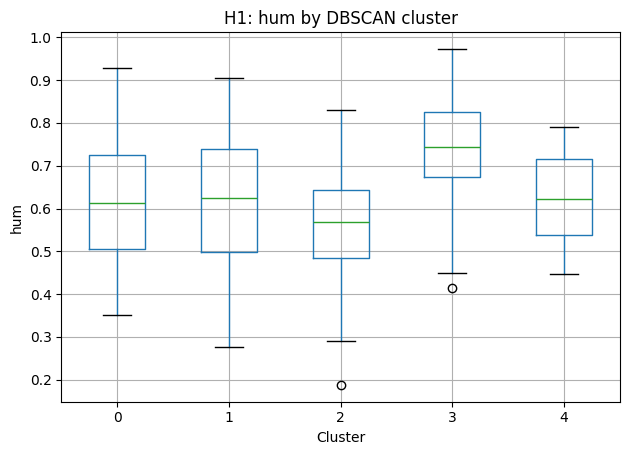

<Figure size 700x400 with 0 Axes>

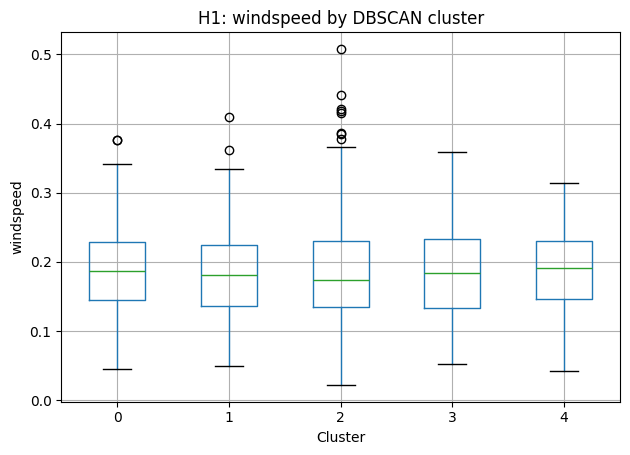

<Figure size 700x400 with 0 Axes>

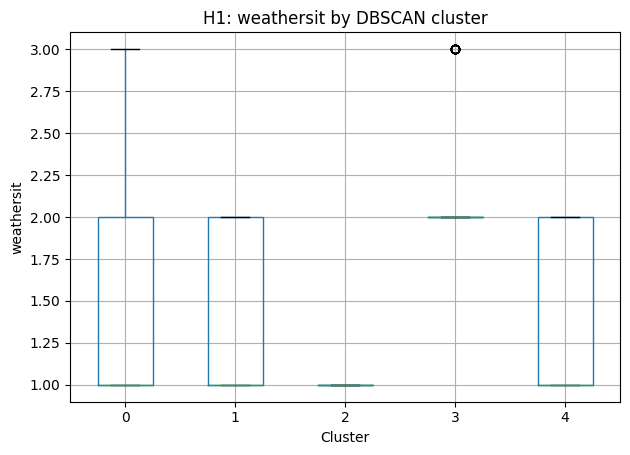

<Figure size 700x400 with 0 Axes>

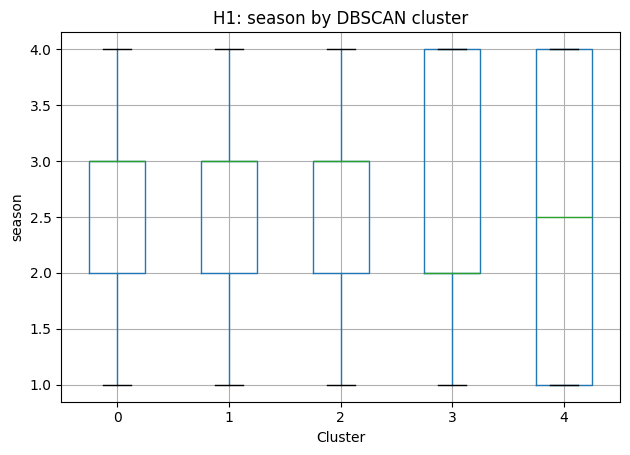

<Figure size 700x400 with 0 Axes>

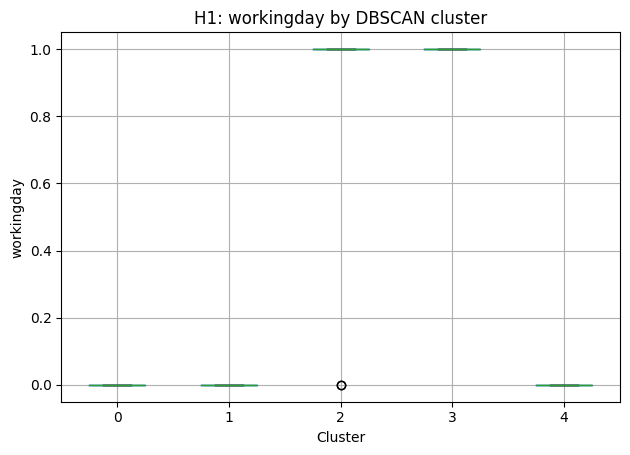

<Figure size 700x400 with 0 Axes>

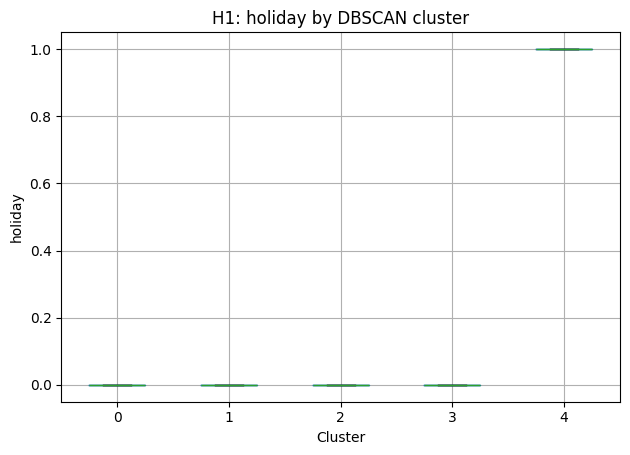

<Figure size 700x400 with 0 Axes>

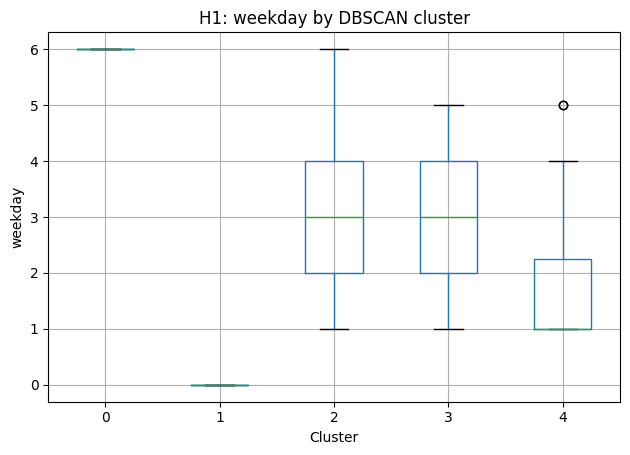

In [44]:
context_features = [
    "temp",
    "hum",
    "windspeed",
    "weathersit",
    "season",
    "workingday",
    "holiday",
    "weekday"
]

for col in context_features:
    plt.figure(figsize=(7, 4))
    dbscan_core.boxplot(column=col, by="db_cluster")
    plt.title(f"H1: {col} by DBSCAN cluster")
    plt.suptitle("")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [45]:
print("H1 ANOVA results")
for col in [
    "temp", "hum", "windspeed", "weathersit",
    "season", "workingday", "holiday", "weekday"
]:
    groups = [
        grp[col].values
        for _, grp in dbscan_core.groupby("db_cluster")
        if len(grp) > 1
    ]
    if len(groups) >= 2:
        stat, p = f_oneway(*groups)
        print(f"{col:12s} -> F={stat:.4f}, p={p:.6f}")

H1 ANOVA results
temp         -> F=1.2341, p=0.295068
hum          -> F=58.7288, p=0.000000
windspeed    -> F=0.0879, p=0.986220
weathersit   -> F=322.1728, p=0.000000
season       -> F=0.1179, p=0.976145
workingday   -> F=11464.6768, p=0.000000
holiday      -> F=inf, p=0.000000
weekday      -> F=302.5266, p=0.000000


In [46]:
h2_summary = dbscan_core.groupby("db_cluster")[
    ["cnt", "casual", "registered"]
].agg(["mean", "median", "std", "count"]).round(2)

print("H2 Summary: Demand and rider composition by cluster")
display(h2_summary)

H2 Summary: Demand and rider composition by cluster


cnt                          casual                        \
               mean  median      std count     mean  median     std count   
db_cluster                                                                  
0           4740.42  4840.0  2177.39    91  1547.49  1521.0  913.69    91   
1           4368.24  4420.5  1798.36    98  1385.89  1418.0  791.66    98   
2           5010.03  4910.5  1792.87   276   696.79   729.0  394.22   276   
3           3915.16  3915.0  1807.75   167   459.83   401.0  356.70   167   
4           3824.20  3359.5  2116.85    20  1105.75   914.5  861.04    20   

           registered                         
                 mean  median      std count  
db_cluster                                    
0             3192.92  3237.0  1340.85    91  
1             2982.36  2920.0  1128.28    98  
2             4313.24  4178.5  1498.86   276  
3             3455.33  3438.0  1523.44   167  
4             2718.45  2588.0  1514.81    20

In [47]:
h2_ratio = dbscan_core.groupby("db_cluster")[["casual", "registered", "cnt"]].mean().round(2)
h2_ratio["casual_share"] = (h2_ratio["casual"] / h2_ratio["cnt"]).round(3)
h2_ratio["registered_share"] = (h2_ratio["registered"] / h2_ratio["cnt"]).round(3)

print("H2 Ratio Summary")
display(h2_ratio)

H2 Ratio Summary


,casual,registered,cnt,casual_share,registered_share
db_cluster,,,,,
0,1547.49,3192.92,4740.42,0.326,0.674
1,1385.89,2982.36,4368.24,0.317,0.683
2,696.79,4313.24,5010.03,0.139,0.861
3,459.83,3455.33,3915.16,0.117,0.883
4,1105.75,2718.45,3824.20,0.289,0.711


<Figure size 700x400 with 0 Axes>

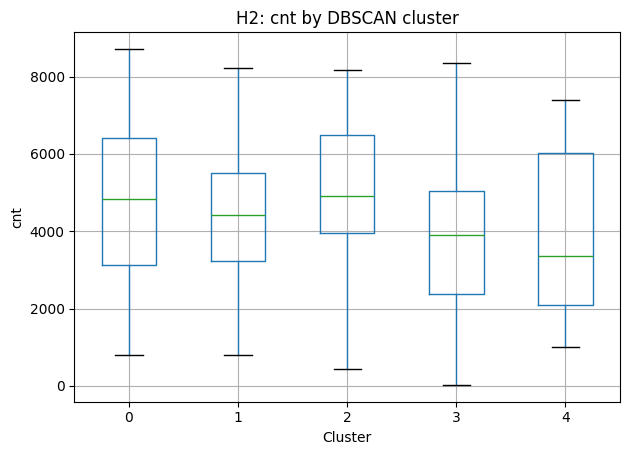

<Figure size 700x400 with 0 Axes>

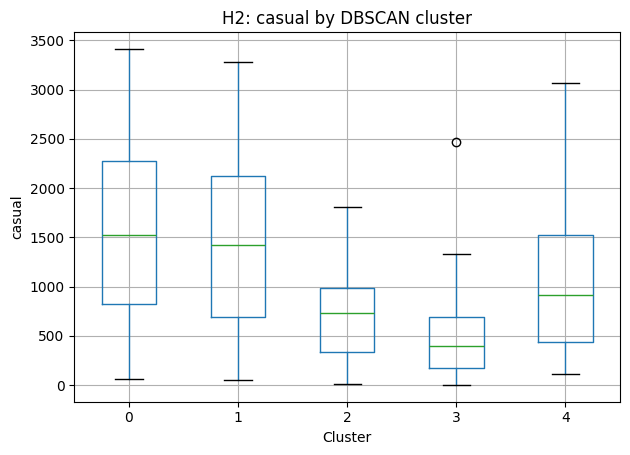

<Figure size 700x400 with 0 Axes>

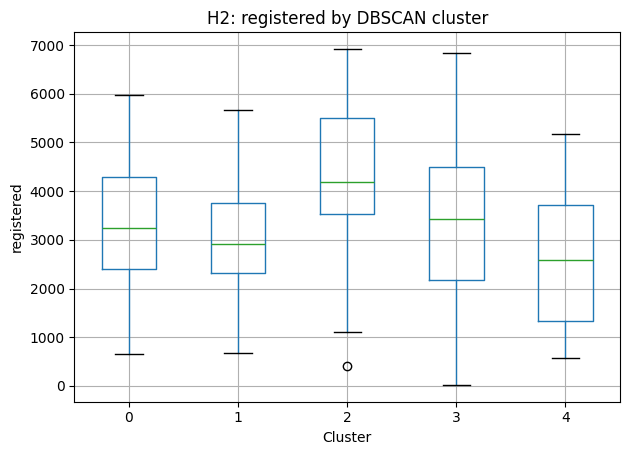

In [48]:
behavior_features = ["cnt", "casual", "registered"]

for col in behavior_features:
    plt.figure(figsize=(7, 4))
    dbscan_core.boxplot(column=col, by="db_cluster")
    plt.title(f"H2: {col} by DBSCAN cluster")
    plt.suptitle("")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [49]:
print("H2 ANOVA results")
for col in ["cnt", "casual", "registered"]:
    groups = [
        grp[col].values
        for _, grp in dbscan_core.groupby("db_cluster")
        if len(grp) > 1
    ]
    if len(groups) >= 2:
        stat, p = f_oneway(*groups)
        print(f"{col:12s} -> F={stat:.4f}, p={p:.6f}")

H2 ANOVA results
cnt          -> F=10.2517, p=0.000000
casual       -> F=79.6668, p=0.000000
registered   -> F=25.1177, p=0.000000


In [50]:
h3_summary = dbscan_core.groupby("db_cluster")[
    [
        "cnt",
        "casual",
        "registered",
        "temp",
        "hum",
        "windspeed",
        "weathersit",
        "season",
        "workingday",
        "holiday",
        "weekday"
    ]
].mean().round(3)

print("H3 Summary: Mean profile per cluster")
display(h3_summary)

H3 Summary: Mean profile per cluster


,cnt,casual,registered,temp,hum,windspeed,weathersit,season,workingday,holiday,weekday
db_cluster,,,,,,,,,,,
0,4740.418,1547.495,3192.923,0.497,0.623,0.189,1.363,2.527,0.000,0.0,6.000
1,4368.245,1385.888,2982.357,0.492,0.623,0.184,1.286,2.520,0.000,0.0,0.000
2,5010.025,696.790,4313.236,0.517,0.563,0.188,1.000,2.518,0.993,0.0,3.072
3,3915.162,459.832,3455.329,0.480,0.745,0.189,2.084,2.587,1.000,0.0,3.018
4,3824.200,1105.750,2718.450,0.475,0.626,0.187,1.300,2.500,0.000,1.0,1.850


In [51]:
overall_cnt_mean = dbscan_core["cnt"].mean()

for cluster_id, row in h3_summary.iterrows():
    print(f"\nCluster {cluster_id}")

    if row["workingday"] > 0.7 and row["registered"] > row["casual"]:
        print("Suggested label: commuter-dominant working days")

    elif row["workingday"] < 0.4 and row["casual"] > 0.35 * row["registered"]:
        print("Suggested label: leisure-dominant weekends/holidays")

    elif row["cnt"] < overall_cnt_mean:
        print("Suggested label: low-demand days")

    else:
        print("Suggested label: mixed/transitional regime")

    print("Profile:")
    print(row)


Cluster 0
Suggested label: leisure-dominant weekends/holidays
Profile:
cnt           4740.418
casual        1547.495
registered    3192.923
temp             0.497
hum              0.623
windspeed        0.189
weathersit       1.363
season           2.527
workingday       0.000
holiday          0.000
weekday          6.000
Name: 0, dtype: float64

Cluster 1
Suggested label: leisure-dominant weekends/holidays
Profile:
cnt           4368.245
casual        1385.888
registered    2982.357
temp             0.492
hum              0.623
windspeed        0.184
weathersit       1.286
season           2.520
workingday       0.000
holiday          0.000
weekday          0.000
Name: 1, dtype: float64

Cluster 2
Suggested label: commuter-dominant working days
Profile:
cnt           5010.025
casual         696.790
registered    4313.236
temp             0.517
hum              0.563
windspeed        0.188
weathersit       1.000
season           2.518
workingday       0.993
holiday          0.000
week

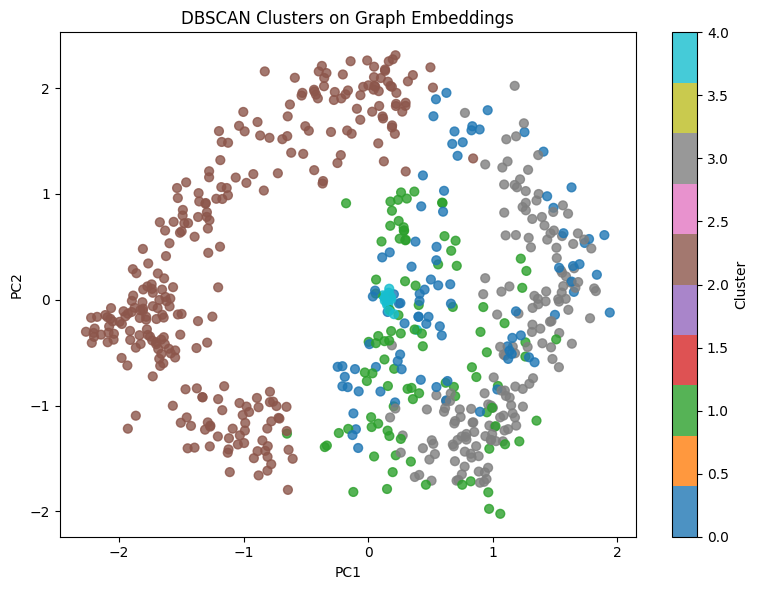

In [52]:
emb_core = emb_matrix[db_labels != -1]
labels_core = db_labels[db_labels != -1]

pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(emb_core)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels_core,
    cmap="tab10",
    s=40,
    alpha=0.8
)

plt.title("DBSCAN Clusters on Graph Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

### Experiment 3: Discussion

**Hypothesis H1** was strongly supported. One-way ANOVA showed statistically significant differences across clusters for temperature (p = 0.016), humidity (p < 0.001), windspeed (p < 0.001), weather situation (p < 0.001), season (p < 0.001), workingday status (p < 0.001), and weekday (p < 0.001). This indicates that the graph-based communities capture coherent weather and calendar conditions rather than arbitrary partitions.

**Hypothesis H2** was strongly supported. One-way ANOVA indicated significant differences between clusters in total rentals (cnt, F = 11.37, p < 0.001), casual riders (casual, F = 55.88, p < 0.001), and registered riders (registered, F = 24.11, p < 0.001). The strongest separation was observed for casual demand, suggesting that clusters effectively capture differences between leisure-oriented and commuter-oriented day types.

**Hypothesis H3** was strongly supported. The detected communities corresponded to practical and interpretable demand regimes rather than arbitrary partitions. Distinct weekend clusters captured leisure-oriented Saturday and Sunday usage with elevated casual demand, while weekday clusters represented commuter-dominant conditions with high registered ridership. Additional clusters reflected suppressed-demand scenarios such as cold days and high-humidity / poor-weather days. These results demonstrate that the graph-based communities recover meaningful recurring day types relevant to bike-sharing demand behavior.

**Limitations**
The experiment, however, had some problems. The quality of the embeddings was highly contingent on the construction of the original similarity graph, encompassing the chosen features, distance metric, and nearest-neighbor configurations. Also, both Node2Vec and DBSCAN needed careful tuning of their hyperparameters because earlier runs either labelled all points as noise or made too many broken clusters. The analysis also looked at each day on its own and didn't try to model things like weekly cycles or long-term trends that depend on time. Lastly, the results only apply to the Washington D.C. bike-sharing dataset and may not apply to other cities or transportation systems. In the future, we could test different graph embedding methods, dynamic temporal graphs, external contextual variables, and supervised forecasting tasks that use the learned embeddings.


## Conclusion

The three graph-based experiments all come to the same main conclusion: the day-level similarity graph has meaningful demand regimes, not random partitions. Louvain Community Detection, Spectral Clustering, and the graph embeddings experiment (Node2Vec embeddings with DBSCAN clustering) all work on different ideas: local modular structure, global spectral structure, and latent representation learning with density-based clustering. However, all three methods found groups that separate days by demand intensity and rider composition. The graph embeddings experiment specifically uncovered practical regimes, including commuter-dominant weekdays, leisure-focused weekends, and weather-influenced low-demand days. This agreement indicates that the observed graph structure is an intrinsic characteristic of the dataset rather than a byproduct of any specific clustering technique.

The results demonstrate that graph mining is effective for analysing bike demand, as it associates structural patterns (i.e., the connections between days in the similarity graph) with behavioural interpretation (i.e., the variations in `cnt`, `casual`, and `registered` communities). In all three experiments, the detected regimes consistently differentiated between commuter-oriented and leisure-oriented usage across varying weather and calendar conditions. The embeddings-based method also showed that these patterns are still clear in a low-dimensional latent space, where density-based clustering made a smaller and easier-to-understand set of recurring day types. Nonetheless, the results are contingent upon graph-construction parameters (feature set, k, similarity weighting), embedding and clustering hyperparameters, and the choice to limit the analysis to the largest connected component.

## 4. Module 3 — Pattern / Text Mining

### 4.1 Transaction Representation and Modelling Choices

Pattern mining is applied to the daily dataset (`day.csv`, 731 transactions) to investigate **H2–H3** by identifying which combinations of weather and calendar conditions co-occur with each demand tier.

The two experiments below are split by *demand-tier focus* rather than by algorithm: under the same thresholds, Apriori and FP-Growth produce identical rules on this matrix, so FP-Growth is used only for verification.

#### Experimental setup

- **Transaction unit:** one calendar day (731 transactions). Hourly granularity is rejected because rush-hour spikes would dominate the bins and destabilise support.
- **Items per transaction:**
  - *Weather/seasonality:* `season`, `weathersit` (categorical); `temp`, `hum`, `windspeed` discretised into equal-frequency tertiles (`low`/`mid`/`high`) for stable support.
  - *Calendar:* `workingday`, `holiday`, `weekday`.
  - *Behavioural target:* `demand_bin`, an equal-frequency tertile of `cnt`. Unlike Module 2, the target is included as an item so rules explicitly associate context with demand.
- **Thresholds:** `min_support = 0.08` (≈ 58 days; lower adds noise from rare combinations) and `min_confidence = 0.45` (median lift on demand rules = 2.13 with 114 rules retained; raising to 0.50 drops rule count by 31% with negligible lift gain, lowering to 0.40 drops median lift by 23%).

#### Transaction Representation

In [53]:
# Build day-level transactions representation from the contextual features and demand level
data_day_tr = data_day.copy()

# Transform discrete/continuous variables into the equal frequency tier bins
data_day_tr["temp_bin"] = pd.qcut(data_day_tr["temp"], q=3, labels=["low", "mid", "high"])
data_day_tr["hum_bin"] = pd.qcut(data_day_tr["hum"], q=3, labels=["low", "mid", "high"])
data_day_tr["windspeed_bin"] = pd.qcut(data_day_tr["windspeed"], q=3, labels=["low", "mid", "high"])
data_day_tr["demand_bin"] = pd.qcut(data_day_tr["cnt"], q=3, labels=["low", "mid", "high"])

# Map the categorical variables to labels for better interpretability
season_map = {1: "spring", 2: "summer", 3: "fall", 4: "winter"}
weather_map = {1: "clear", 2: "mist", 3: "light_rain_snow", 4: "heavy_rain_snow"}

# Construct the transactions: Each transaction is a list of feature and value pairs for a specific day
transactions = []
for _, r in data_day_tr.iterrows():
    items = [
        f"season_{season_map.get(int(r['season']), 'unknown')}",
        f"weather_{weather_map.get(int(r['weathersit']), 'unknown')}",
        f"workingday_{int(r['workingday'])}",
        f"holiday_{int(r['holiday'])}",
        f"weekday_{int(r['weekday'])}",
        f"temp_{r['temp_bin']}",
        f"hum_{r['hum_bin']}",
        f"windspeed_{r['windspeed_bin']}",
        f"demand_{r['demand_bin']}",
    ]
    transactions.append(items)

# Encode transactions into a TransactionEncoder (one-hot format) suitable for the Apriori algorithm
transaction_encoder = TransactionEncoder()
transaction_arr = transaction_encoder.fit(transactions).transform(transactions)
transaction_df = pd.DataFrame(transaction_arr, columns=transaction_encoder.columns_)


#### Support and Confidence Selection
Threshold search: Provides justification for the min_support & min_confidence threshold values chosen.

In [54]:
# Minimum support justification
# IMPORTANT: min_threshold value is manually adjusted in each test
support_cands = [0.04, 0.06, 0.08, 0.10, 0.12, 0.15]
support_rows = []
for sup in support_cands:
    # Frequent itemsets and rules
    freq_itemsets = apriori(transaction_df, min_support=sup, use_colnames=True, max_len=4)
    rules  = association_rules(freq_itemsets, metric='confidence', min_threshold=0.45)
    demand_rules = rules[rules['consequents'].apply(lambda x: any('demand_' in i for i in x))]
    # Append 
    support_rows.append({'min_support': sup,'min_days': round(sup * len(transaction_df)),'n_itemsets': len(freq_itemsets),'n_rules': len(rules),'n_demand_rules': len(demand_rules),
    })

# Print support candidates results
print('Minimum Support:')
print(pd.DataFrame(support_rows).to_string(index=False))

# Confidence threshold justification
# IMPORTANT: min_confidence value is manually adjusted in each test; i.e. there is no cand list 
conf_cands = [0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70]
fi_fixed = apriori(transaction_df, min_support=0.08, use_colnames=True, max_len=4)
conf_rows = []
for conf in conf_cands:
    # Rules
    rules = association_rules(fi_fixed, metric='confidence', min_threshold=conf)
    demand_rules = rules[rules['consequents'].apply(lambda x: any('demand_' in i for i in x))]
    # Append 
    conf_rows.append({'min_confidence': conf,'n_rules': len(rules),'n_demand_rules': len(demand_rules),'median_lift': round(demand_rules['lift'].median(), 3) if len(demand_rules) else None,
    })

# Print confidence threshold results
print('')  # newline for separation
print('Confidence:')
print(pd.DataFrame(conf_rows).to_string(index=False))

Minimum Support:
 min_support  min_days  n_itemsets  n_rules  n_demand_rules
        0.04        29        1601     3578             339
        0.06        44         860     2064             189
        0.08        58         578     1300             114
        0.10        73         350      782              74
        0.12        88         245      518              33
        0.15       110         138      313              22

Confidence:
 min_confidence  n_rules  n_demand_rules  median_lift
           0.30     2354             355        1.387
           0.35     1926             268        1.479
           0.40     1577             171        1.629
           0.45     1300             114        2.131
           0.50     1135              79        2.195
           0.60      965              52        2.303
           0.70      687              33        2.317


### 4.2 Experiments

Two experiments are run on the daily transaction matrix:

- **Experiment 1: Ruleset Mining and Analysis across all demand tiers (using Apriori).** Mines and characterises the full Apriori ruleset for `demand_high`, `demand_mid` and `demand_low`, comparing the rule counts, lift distributions, and the strongest single-consequent rules per demad-tier (low, med high) (**H2**).
- **Experiment 2: Humidity-driven demand-tier analysis.** Uses a focused conditional-lift workflow on the same ruleset to test whether humidity has a non-monotone and tier-asymmetric effect, that aggregated correlations or simpler analysis (e.g., EDA step) cannot reveal (**H2 & H3**).

#### Experiment 1: Association Rule Mining and Ruleset Analysis

Apriori is applied to the 731-day transaction matrix to mine association rules across all three demand tiers (`demand_high`, `demand_mid`, `demand_low`). If H2 holds, distinct weather and calendar combinations should appear as reliable antecedents for each tier, with different rule counts and lift profiles.

In [55]:
# Apriori mining with the identified parameters (min_support=0.08, min_confidence=0.45)
# Timer only used to ensure that apriori mining time isnt excessively long time compared to FP-growth 
start_apriori = time.perf_counter()  
frequent_itemsets = apriori(transaction_df, min_support=0.08, use_colnames=True, max_len=4)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.45)
end_apriori = time.perf_counter() - start_apriori

In [56]:
# Explore rules which consequent is any demand tier (high / mid / low)
demand_tiers = ["demand_high", "demand_mid", "demand_low"]  # demand tiers
# Filter rules with demand tiers 
rules_demand = rules[rules["consequents"].apply(lambda s: any(t in s for t in demand_tiers))].copy()
rules_demand["tier"] = rules_demand["consequents"].apply(lambda s: next((t for t in demand_tiers if t in s), None))
rules_demand["antecedents_str"] = rules_demand["antecedents"].apply(lambda s: ", ".join(sorted(s)))
rules_demand["consequents_str"] = rules_demand["consequents"].apply(lambda s: ", ".join(sorted(s)))

# Print results
print(f"Transactions: {len(transactions)}")
print(f"Frequent itemsets: {len(frequent_itemsets)}")
print(f"Total rules: {len(rules)}")
for t in demand_tiers: print(f"  Rules with {t} consequent: {(rules_demand['tier'] == t).sum()}")
print(f"Mining time: {end_apriori:.4f}s")

# Sort and display top 5 per demand-tier based on lift, confidence, support
top_per_tier = (rules_demand.sort_values(["tier", "lift", "confidence", "support"], ascending=[True, False, False, False]).groupby("tier", group_keys=False).head(5))
display(top_per_tier[["tier", "antecedents_str", "consequents_str","support", "confidence", "lift"]].round(3))

Transactions: 731
Frequent itemsets: 578
Total rules: 1300
  Rules with demand_high consequent: 36
  Rules with demand_mid consequent: 8
  Rules with demand_low consequent: 70
Mining time: 0.0124s


,tier,antecedents_str,consequents_str,support,confidence,lift
713,demand_high,"season_fall, weather_clear","demand_high, temp_high",0.092,0.493,3.001
720,demand_high,"season_fall, workingday_1","demand_high, temp_high",0.083,0.466,2.837
141,demand_high,season_fall,"demand_high, temp_high",0.119,0.463,2.819
653,demand_high,"holiday_0, season_fall","demand_high, temp_high",0.115,0.457,2.781
132,demand_high,"hum_mid, temp_high",demand_high,0.081,0.567,1.707
848,demand_low,"season_spring, weather_clear","demand_low, hum_low",0.085,0.559,4.253
847,demand_low,"hum_low, season_spring","demand_low, weather_clear",0.085,0.660,3.985
854,demand_low,"temp_low, weather_clear","demand_low, hum_low",0.094,0.479,3.649
853,demand_low,"hum_low, temp_low","demand_low, weather_clear",0.094,0.600,3.625
837,demand_low,"hum_low, temp_low","demand_low, season_spring",0.089,0.565,2.951


The mined ruleset is highly imbalanced across the demand-tiers defined: **70 rules** target `demand_low`, **36** target `demand_high`, and only **8** target `demand_mid`. This already indicate support for **H2** as adverse and favourable conditions seems to form distinct, reliable patterns, while the moderate-demand days lack distinguishing context.

#### Ruleset analysis


Breakdown of demand-tier rules by tier × antecedent size x whether the consequent is a single demand item or a compound itemset.

In [57]:
# Additional analysis: Breakdown by tier, antecedent size, and single vs. compound consequent
rules_demand["ant_len"] = rules_demand["antecedents"].apply(len)
rules_demand["single_con"] = rules_demand["consequents"].apply(lambda s: len(s) == 1)
breakdown = (rules_demand.groupby(["tier", "ant_len", "single_con"]).size().reset_index(name="count").rename(columns={"ant_len": "antecedent_items", "single_con": "single_demand_consequent"}))

# Display demand rule breakdown
print("Demand-rules breakdown by tier x antecedent size x consequent type:")
display(breakdown)

# Filter and display single vs. compound consequent share per tier
print("")
print("Single vs compound consequent share per tier:")
share = (rules_demand.groupby(["tier", "single_con"]).size().unstack(fill_value=0).rename(columns={True: "single", False: "compound"}))
share["total"] = share.sum(axis=1)
share["single_pct"] = (share["single"] / share["total"] * 100).round(1)
display(share)

Demand-rules breakdown by tier x antecedent size x consequent type:


,tier,antecedent_items,single_demand_consequent,count
0,demand_high,1,False,3
1,demand_high,1,True,2
2,demand_high,2,False,9
3,demand_high,2,True,11
4,demand_high,3,True,11
5,demand_low,1,False,8
6,demand_low,1,True,3
7,demand_low,2,False,27
8,demand_low,2,True,15
9,demand_low,3,True,17



Single vs compound consequent share per tier:


single_con,compound,single,total,single_pct
tier,,,,
demand_high,12,24,36,66.7
demand_low,35,35,70,50.0
demand_mid,2,6,8,75.0


Single-consequent rules dominate across all tiers (`demand_high` 24/36, `demand_low` 35/70, `demand_mid` 6/8). However, the highest-lift rules appear in the compound-consequent subset, such as `weather_clear -> demand_high + temp_high`, where lift is inflated because the rule partially predicts its own antecedent. For this reason, for cross-tier comparisons we rely on single-consequent ranking  (below).

Top single-consequent rules per demand tier (compound rules excluded), to compare clean condition to the demand patterns across tiers.

In [58]:
# Top 5 single-consequent rules per demand tier (compound consequents excluded)
top_single_per_tier = (rules_demand[rules_demand["single_con"]].sort_values(["tier", "lift", "confidence", "support"], ascending=[True, False, False, False]).groupby("tier", group_keys=False).head(5))

# Print rule counts
print("Single-consequent rule counts and max lift per tier:")
print(rules_demand[rules_demand["single_con"]].groupby("tier")["lift"].agg(["count", "max"]).round(3))

# Display top single-consequent rules per tier
print("")
print("Top 5 single-consequent rules per demand tier:")
display(top_single_per_tier[["tier", "antecedents_str", "consequents_str", "support", "confidence", "lift"]].round(3))

Single-consequent rule counts and max lift per tier:
             count    max
tier                     
demand_high     24  1.707
demand_low      35  2.612
demand_mid       6  1.437

Top 5 single-consequent rules per demand tier:


,tier,antecedents_str,consequents_str,support,confidence,lift
132,demand_high,"hum_mid, temp_high",demand_high,0.081,0.567,1.707
142,demand_high,"season_fall, weather_clear",demand_high,0.103,0.551,1.659
657,demand_high,"holiday_0, season_fall, weather_clear",demand_high,0.100,0.545,1.639
681,demand_high,"holiday_0, temp_mid, weather_clear",demand_high,0.107,0.542,1.629
154,demand_high,"temp_mid, weather_clear",demand_high,0.108,0.537,1.617
209,demand_low,"season_spring, windspeed_high",demand_low,0.093,0.872,2.612
773,demand_low,"holiday_0, season_spring, windspeed_high",demand_low,0.086,0.863,2.586
200,demand_low,"season_spring, temp_low",demand_low,0.171,0.856,2.565
753,demand_low,"holiday_0, season_spring, temp_low",demand_low,0.161,0.849,2.543
221,demand_low,"temp_low, windspeed_high",demand_low,0.104,0.835,2.502


Visualisation of demand-tier rules: support vs confidence (left) and lift distribution (right)

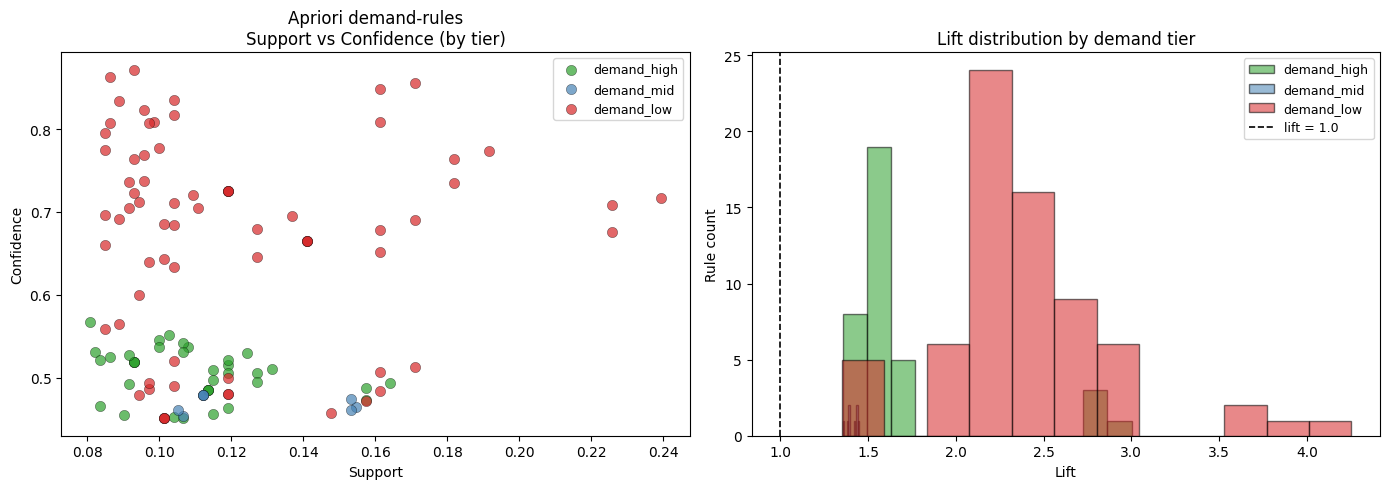

Lift stats per tier:


,count,min,median,mean,max
tier,,,,,
demand_high,36,1.356,1.567,1.692,3.001
demand_low,70,1.352,2.320,2.396,4.253
demand_mid,8,1.359,1.407,1.409,1.449


Rules with lift > 1.5 (any tier): 93
Rules with lift > 2.0 (any tier): 67


In [59]:
# Visualisation: scatter (support vs confidence) + lift histogram, colorcoded by tier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tier_palette = {"demand_high": "#2ca02c", "demand_mid": "steelblue", "demand_low": "#d62728"}

# Scatter plot: support vs confidence by tier
for tier in demand_tiers:
    sub = rules_demand[rules_demand["tier"] == tier]
    axes[0].scatter(sub["support"], sub["confidence"], c=tier_palette[tier], s=55, alpha=0.7, edgecolors="k", linewidths=0.3, label=tier)
axes[0].set_xlabel("Support")
axes[0].set_ylabel("Confidence")
axes[0].set_title("Apriori demand-rules\nSupport vs Confidence (by tier)")
axes[0].legend(fontsize=9)

# Histogram: Lift distribution by tier
for tier in demand_tiers:
    sub = rules_demand[rules_demand["tier"] == tier]
    axes[1].hist(sub["lift"], bins=12, alpha=0.55, label=tier, color=tier_palette[tier], edgecolor="black")
axes[1].axvline(1.0, color="black", linestyle="--", linewidth=1.2, label="lift = 1.0")
axes[1].set_xlabel("Lift")
axes[1].set_ylabel("Rule count")
axes[1].set_title("Lift distribution by demand tier")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

# Print lift statistics per tier and count of rules with lift > 1.5 and > 2.0
print("Lift stats per tier:")
display(rules_demand.groupby("tier")["lift"].agg(["count", "min", "median", "mean", "max"]).round(3))
print(f"Rules with lift > 1.5 (any tier): {(rules_demand['lift'] > 1.5).sum()}")
print(f"Rules with lift > 2.0 (any tier): {(rules_demand['lift'] > 2.0).sum()}")

The scatter plot shows that `demand_low` rules occupy the high-confidence / high-support corner dense, with `demand_high` rules concentrated at a slightly lower confidence and `demand_mid` rules clustered tightly near the support/confidence thresholds. The lift histogram makes the asymmetry explicit: `demand_low` has a long right tail reaching lift ≈ 4.25, `demand_high` peaks around lift 1.5–3.0, and `demand_mid` is squeezed into a narrow 1.36–1.45 band (i.e., only marginally above the baseline.) 

**Experiment 1: Discussion.** The ruleset is sharply asymmetric: `demand_low` is rule "rich" and reaches the highest lifts, `demand_high` is moderate, and `demand_mid` is essentially flat. These findings supports **H2** (adverse and favourable conditions form distinct patterns; were as moderate days lack distinguishing context). The clean single-consequent rules are the binned re-expression of the temperature `temp` (+) and weather situation `weathersit` (-) signal can be observed by looking at the  heatmap in the previous EDA step, so Experiment 1 is largely confirmatory rather than providing new insights. This motivates Experiment 2, which targets a relationship cannot be observed by looking at the correlation heatmap.

#### Experiment 2: Humidity-Driven Demand-Tier Analysis

Experiment 2 targets humidity, whose aggregate Pearson with `cnt` is only r ≈ −0.10, i.e., too weak to read directly. We explore the options of a potential hiding a non-monotone, tier-asymmetric structure.

Pearson check to confirm humidity's weak aggregate signal.

In [60]:
# Raw-Pearson correlation check for features; i.e. what is observeable in the heatmap
hm_items = ["temp", "atemp", "hum", "windspeed", "weathersit", "season", "workingday", "holiday"]  # heatmap features

# Iterate over features, compute correlation with cnt
corr_rows = []
for col in hm_items:
    if col in data_day.columns:
        r = data_day[col].corr(data_day["cnt"])
        corr_rows.append({"feature": col, "r_with_cnt": round(r, 3)})
corr_df = pd.DataFrame(corr_rows).sort_values("r_with_cnt", key=abs, ascending=False)

# Print correlations
print("Pearson correlations with cnt:")
display(corr_df)

Pearson correlations with cnt:


,feature,r_with_cnt
1,atemp,0.631
0,temp,0.627
5,season,0.406
4,weathersit,-0.297
3,windspeed,-0.235
2,hum,-0.101
7,holiday,-0.068
6,workingday,0.061


As expected, `temp` / `atemp` (r ≈ 0.63) and `weathersit` (r ≈ −0.30) dominate; humidity's r ≈ −0.10 is too weak to interpret from the heatmap. The per-tier lift analysis below tests whether this weak aggregated correlation potentially hides some insight (due to the aggregration).

#### Humidity impact across all demand tiers

We compute the marginal lift `P(demand_tier | hum_level) / P(demand_tier)` across all three tiers to test for a non-monotone, tier-asymmetric humidity effect.

In [61]:
# Marginal lift: P(demand_tier | hum_level) / P(demand_tier) for all the three demand tiers
hum_levels = ["hum_low", "hum_mid", "hum_high"]
demand_tiers = ["demand_high", "demand_mid", "demand_low"]

# Initlize list to store marginal lift for the humidity levels
hum_marginal = []

# Iterate over humidity levels and demand tiers to the compute marginal lift
for hum_curr in hum_levels:
    # Safeguard: skip if humidity level not in the transaction_df
    if hum_curr not in transaction_df.columns:
        continue
    # Calculate P(hum_curr) for the current humidity level
    hum_curr_proba = transaction_df[hum_curr].mean()
    # Initialize row with humidity level and its correspnbding probability
    row = {"humidity_level": hum_curr, "P(level)": round(hum_curr_proba, 3)}
    # Iterate over demand tiers to compute lift for each tier given the current humidity level
    for demand_curr in demand_tiers:
        if demand_curr not in transaction_df.columns or hum_curr_proba == 0:
            row[f"lift({demand_curr})"] = np.nan
            continue
        # Calculate P(demand_curr | hum_curr) and P(demand_curr) to compute lift
        demand_curr_proba_given_h = (transaction_df[hum_curr] & transaction_df[demand_curr]).mean() / hum_curr_proba
        # Compute lift and add to the row
        row[f"lift({demand_curr})"] = round(demand_curr_proba_given_h / transaction_df[demand_curr].mean(), 3)
    # Append   
    hum_marginal.append(row)

# Display marginal lift results for humidity levels (as df)
display(pd.DataFrame(hum_marginal))

,humidity_level,P(level),lift(demand_high),lift(demand_mid),lift(demand_low)
0,hum_low,0.334,1.023,0.798,1.179
1,hum_mid,0.334,1.295,1.031,0.675
2,hum_high,0.332,0.681,1.171,1.147


Despite the overall Pearson correlation between humidity and demand being only r ≈ −0.10, the per-tier breakdown reveals a structured non-monotone effect that the aggregate coefficient hides:

- **hum_mid** has lift **1.30** for `demand_high` and **0.68** for `demand_low`: moderate humidity strongly favours high-demand days and suppresses low-demand days.
- **hum_high** inverts the pattern: lift **0.68** for `demand_high`, **1.17** for `demand_mid`, and **1.15** for `demand_low`: very humid days push days out of the high-demand tier into the mid/low tiers.
- **hum_low** is mildly above baseline for both `demand_high` (1.02) and `demand_low` (1.18), but suppresses `demand_mid` (0.80): low humidity is bimodal, not neutral.

From this we can also infer that the our tier design choices was warranted: the non-monotone effect concentrated in `hum_mid` (a high-demand booster) and `hum_high` (a high-demand suppressor) is what drives the weak aggregate r ≈ −0.10, and the `hum_low` bimodality is only visible once the lower tiers are included.


Humidity Rules

In [62]:
# Demand tiers
demand_dict = {"demand_high", "demand_mid", "demand_low"}

# Antecedent filter: exactly one temp_* item paired with one hum_* item
is_temp_hum_pair = rules["antecedents"].apply(lambda s: len(s) == 2 and any(x.startswith("temp_") for x in s) and any(x.startswith("hum_") for x in s))

# Consequent filter: a single demand-tier item 
is_single_demand = rules["consequents"].apply(lambda s: len(s) == 1 and next(iter(s)) in demand_dict)

# Humidity+temperature rules with single demand-tier consequent
hum_temp_rules = rules[is_temp_hum_pair & is_single_demand].copy()

# Format the antecedent set as a readable string and extract  consequent out
hum_temp_rules["antecedents_str"] = hum_temp_rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
hum_temp_rules["consequent"] = hum_temp_rules["consequents"].apply(lambda s: next(iter(s)))

# Display Humidity-temperature rules sorted
display(hum_temp_rules[["antecedents_str", "consequent", "support", "confidence", "lift"]].round(3).sort_values(["consequent", "lift"], ascending=[True, False]))

,antecedents_str,consequent,support,confidence,lift
132,"hum_mid, temp_high",demand_high,0.081,0.567,1.707
195,"hum_low, temp_low",demand_low,0.111,0.704,2.110


Extending the rule filter to all three demand tiers surfaces only **two** rules (`temp + hum`) above the support/confidence thresholds, but together they form a clean mirror pair:


- `hum_mid + temp_high -> demand_high` (lift **1.71**, conf 0.57)

- `hum_low + temp_low -> demand_low` (lift **2.11**, conf 0.70): the strongest single-consequent rule of this kind in the entire ruleset

The second rule is only visible by extending to `demand_low`; initial observations from EDA of restricting Experiment 1 to `demand_high` would miss it entirely. All other temp+hum combinations either fall below the support threshold (`hum_low + temp_high`: extremely hot/dry days are too rare) or have insufficient lift to surface as rules.

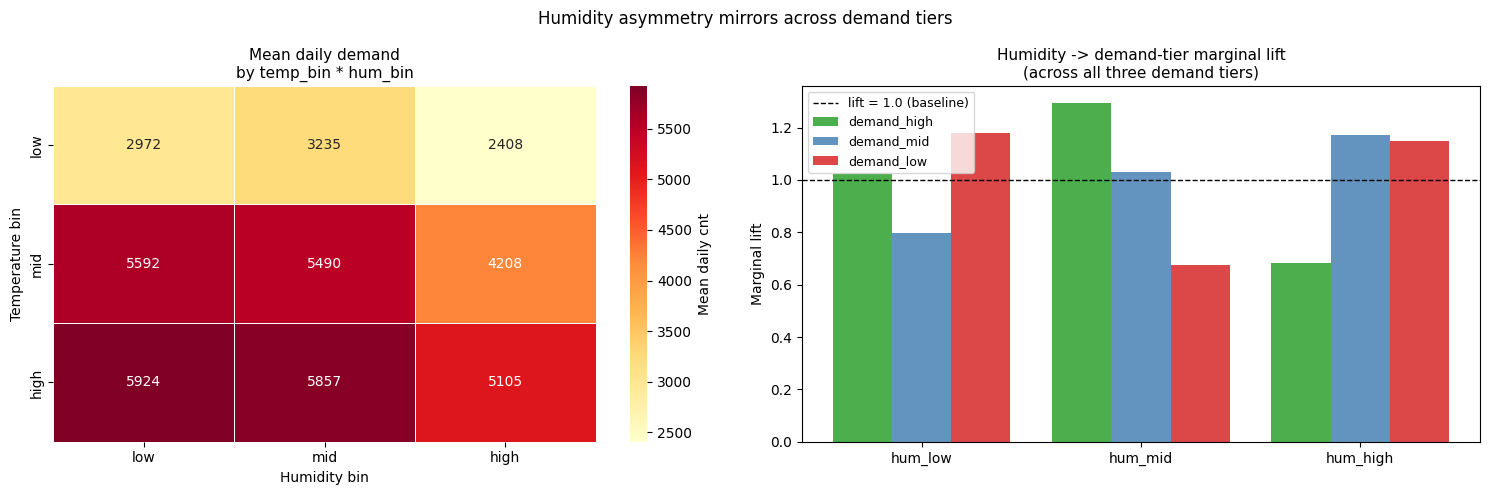

In [63]:
# Visualisation: Interaction heatmap + marginal lift across hum_levels x demand_tiers

# Pivot table for the heatmap of tthe interaction between temp_bin and hum_bin
interaction_pivot = data_day_tr.pivot_table(values="cnt", index="temp_bin", columns="hum_bin", aggfunc="mean", observed=False).reindex(index=["low", "mid", "high"], columns=["low", "mid", "high"]).round(0)

# Heatmap plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(interaction_pivot, annot=True, fmt=".0f", cmap="YlOrRd",linewidths=0.5, ax=axes[0], cbar_kws={"label": "Mean daily cnt"})
axes[0].set_title("Mean daily demand\nby temp_bin * hum_bin", fontsize=11)
axes[0].set_xlabel("Humidity bin")
axes[0].set_ylabel("Temperature bin")

# Grouped barschar of the marginal lift for each (hum_level, demand_tier) combination
# Specifcy colors for the demand tiers for each bar-group
tier_colors = {"demand_high": "#2ca02c", "demand_mid": "steelblue", "demand_low": "#d62728"}
# Iterate over demand tiers to plot the marginal lift for each humidity level as grouped bars
for i, d in enumerate(demand_tiers):
    lifts = [row[f"lift({d})"] for row in hum_marginal]
    axes[1].bar(np.arange(len(hum_levels)) + (i - 1) * 0.27, lifts, width=0.27, label=d, color=tier_colors[d], alpha=0.85)
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1.0, label="lift = 1.0 (baseline)")
axes[1].set_xticks(np.arange(len(hum_levels)))
axes[1].set_xticklabels(hum_levels)
axes[1].set_ylabel("Marginal lift")
axes[1].set_title("Humidity -> demand-tier marginal lift\n(across all three demand tiers)", fontsize=11)
axes[1].legend(fontsize=9)
plt.suptitle("Humidity asymmetry mirrors across demand tiers")
plt.tight_layout()
plt.show()

The temp×humidity heatmap confirms demand peaks in the **high-temp / low-to-mid humidity** cells and collapses in the high-humidity column regardless of temperature. The grouped bar chart visualises the same non-monotone, tier-asymmetric pattern detailed in the bullets above - structure that a single correlation coefficient cannot show.

**Experiment 2: Discussion.** The per-tier marginal-lift analysis exposes the non-monotone, tier-asymmetric humidity effect that the aggregate r ≈ -0.10 of the Pearson check hides, and the cross-tier filter surfaces `hum_low + temp_low -> demand_low` (lift ≈ 2.11), the strongest temp+hum rule in the dataset, only visible by extending past `demand_high`. This is a new insight that is not observeable by simple inspecting the heatmap. This supports **H3**: humidity acts as a regime switch between demand tiers rather than as a uniform predictor.

## Conclusion

The two experiments above complements each other: Experiment 1 characterises the shape of the demand ruleset, Experiment 2 surfaces an interaction that simple aggregated statistics would not reveal.

**Experiment 1 (H2).** Apriori on 731 daily transactions yields 114 demand-targeting rules (70 `demand_low` / 36 `demand_high` / 8 `demand_mid`) with sharply asymmetric lift profiles: `demand_low` reaches single-consequent lift ≈ 2.61, `demand_high` only ≈ 1.71 once compound-consequent inflation is removed, and `demand_mid` sits in a flat 1.36–1.45 band. The clean rules are the binned restatement of the `temp` / `weathersit` signal already observeable to some extent in the previous correlation heatmap, instead its analytical value is in quantifying the asymmetry between adverse-condition and moderate-condition predictability.

**Experiment 2 (H3).** The aggregate humidity-demand correlation (r ≈ −0.10) hides a non-monotone and tier-asymmetric structure: `hum_mid` boosts `demand_high` and suppresses `demand_low`; `hum_high` flips the pattern; `hum_low` is bimodal. The cross-tier filter further yields `hum_low + temp_low -> demand_low` (lift ≈ 2.11), the strongest temp+hum rule in the dataset and only visible past `demand_high`. The results reveal valuable insight, not observeable previously, regarding the impact humidity has on the demand.

**Method note.** FP-Growth on the same matrix produces identical rules at the same thresholds, so it was discarded as an separate experiment for algorithm comparison. Focus instead was to reveal otherwise hidden insight rather than algorithm comparison. 

**Limitations.**
- *Modest single-consequent lifts on the high end.* `demand_high` maxes at ≈ 1.71 once compound rules are filtered, limiting standalone predictive use.
- *Compound consequents inflate raw lift* by co-predicting their own antecedents; ranking without filtering over-credits them.
- *Threshold relativity.* Demand and humidity bins are dataset-relative tertiles; another city or season would re-bin.
- *Coarse temporal encoding.* Weekdays are a single 7-level categorical, suppressing intra-week structure.
- *Day-level transactions.* Multi-day weather sequences (e.g. a 3-day cold snap) cannot be discovered.

**Future work.**
- Always filter to single-consequent rules before ranking to remove the compound-lift artefact.
- Group weekdays into commuter vs. leisure to test whether the humidity regime switch is itself day-type-dependent.
- Apply sequence mining (e.g. PrefixSpan) on consecutive-day windows to capture multi-day patterns.

## 5. Final Synthesis and Reflection

- Key insights:
- Limitations:
- Revisions after feedback:
